# LeafletFA Splicing Analysis - Mouse Foundation Model
 
### This notebook analyzes the relationship between splicing factors (LeafletFA) and gene expression factors (scVI, NMF, PCA) for age prediction across different cell types.


## 1. Setup and Imports

In [1]:
# %%
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
from pathlib import Path
import os
import sys
from collections import defaultdict

# Statistical libraries
from scipy.stats import spearmanr, pearsonr
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy import stats
import scipy.sparse as sp
from statsmodels.stats.multitest import multipletests

# Machine learning
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Specialized libraries
import scanpy as sc
from adjustText import adjust_text
from tqdm import tqdm

## 2. Configuration and Path Setup

In [2]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

class Config:
    # Base directories
    BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION"
    RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results"
    
    # Data paths
    GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_scvi_model_latent_20_2025-08-04.h5ad"
    # GE_ANNDATA_NMF_PATH = f"{BASE_DIR}/NMF/ge_adata_with_NMF_standard_20_1024_2025-08-03.h5ad"
    
    # GSEA paths
    GSEA_BASE_PATH = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/HUMAN/20250805"
    
    # Reference files
    AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
    RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"
    ATSE_FILE_PATH = f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
    
    # Main parameters to change
    MODEL_TRAIN_DATE = "2025-07-31"
    MODEL_ANALYSIS_DATE = "2025-08-01"
    PARAM_ID = 1
    
    # Genome database
    HUMAN_DB_FILE = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/v45hg38"

# Generate auto paths
def setup_paths(config):
    """Generate all necessary paths from configuration."""
    param_results_dir = f"{config.RESULTS_BASE_DIR}/{config.MODEL_TRAIN_DATE}/{config.MODEL_ANALYSIS_DATE}/param_id_{config.PARAM_ID}"
    data_dir = f"{param_results_dir}/data"
    model_outputs_dir = f"{config.BASE_DIR}/Leaflet/leafletFAmodel/{config.MODEL_TRAIN_DATE}"
    output_dir = f"{param_results_dir}/analysis_outputs"
    
    paths = {
        'data_dir': data_dir,
        'output_dir': output_dir,
        'splice_adata_path': f"{data_dir}/splice_adata_PHI_psi_var_obs.h5ad",
        'pi_values_path': f"{data_dir}/PI_values.npy",
        'perplexity_path': f"{data_dir}/cell_metadata_with_perplexity_param_id_{config.PARAM_ID}.csv.gz",
        'diff_spl_path': f"{data_dir}/differential_splicing_results.csv",
        'model_path': f"{model_outputs_dir}/run_{config.PARAM_ID}/leafletfa_model.pkl.xz"
    }
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    return paths

config = Config()
paths = setup_paths(config)

print(f"Configuration set for param_id {config.PARAM_ID}")
print(f"Output directory: {paths['output_dir']}")

Configuration set for param_id 1
Output directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs


## 3. Custom Module Imports

In [3]:
# Import LeafletFA differential splicing code
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"
utils_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/"

if src_path not in sys.path:
    sys.path.append(src_path)
if utils_path not in sys.path:
    sys.path.append(utils_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds
from utils import *
from figure_plotting import *
from atse_viz import *
import gffutils

# Load genome database
db_human = gffutils.FeatureDB(config.HUMAN_DB_FILE, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


## 4. Data Loading Functions

In [4]:
def load_gsea_data(base_path):
    """Load all GSEA data files."""
    gsea_data = {}
    
    methods = ['scvi'] #, 'nmf', 'pca']
    for method in methods:
        gsea_data[method] = {
            'full': pd.read_csv(f"{base_path}/gsea_results_comprehensive_{method}.tsv.gz", sep="\t")
        }
    
    return gsea_data

def load_reference_genes(aging_genes_path, rbp_file_path):
    """Load aging genes and RBP genes."""
    aging_genes_mouse, aging_genes_human = load_aging_genes(aging_genes_path)
    rbps = load_rbp_genes(rbp_file_path)
    
    # Process gene names
    rbps = rbps["gene_name"]    
    return aging_genes_human, rbps

def load_main_datasets(config, paths):
    """Load main AnnData objects and associated data."""
    print("Loading main datasets...")
    
    # Load gene expression data
    # ge_adata_nmf = ad.read_h5ad(config.GE_ANNDATA_NMF_PATH)
    ge_adata = ad.read_h5ad(config.GE_ANNDATA_scVI_PATH)
    
    # Combine data
    # assert np.all(ge_adata.obs_names == ge_adata_nmf.obs_names), "Cell ID mismatch"
    # assert np.all(ge_adata.var_names == ge_adata_nmf.var_names), "Gene name mismatch"
    
    # ge_adata.obsm["X_nmf_standard_mb"] = ge_adata_nmf.obsm["X_nmf_standard_mb"]
    # ge_adata.varm["nmf_standard_mb_components"] = ge_adata_nmf.varm["nmf_standard_mb_components"]
    # ge_adata.obsm["X_pca"] = ge_adata_nmf.obsm["X_pca"]
    # ge_adata.varm["pca_loadings"] = ge_adata_nmf.varm["pca_loadings"]
    
    # Add gene names if missing
    if "gene_name" not in ge_adata.var.columns:
        ge_adata.var["gene_name"] = ge_adata.var_names
    if "cell_id" not in ge_adata.obs.columns:
        ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]
    
    # Load splicing data
    splice_adata = ad.read_h5ad(paths['splice_adata_path'])
    pi = np.load(paths['pi_values_path'])
    diff_spl = pd.read_csv(paths['diff_spl_path'])
    perplexity_df = pd.read_csv(paths['perplexity_path']).set_index("cell_id")
    
    print(f"Loaded splice_adata: {splice_adata.shape}")
    print(f"Loaded ge_adata: {ge_adata.shape}")
    
    return ge_adata, splice_adata, pi, diff_spl, perplexity_df

## 5. Data Processing Functions

In [5]:
def process_splice_data(splice_adata, pi, diff_spl, perplexity_df):
    """Process and reorder splicing data based on PI values."""
    print("Processing splicing data...")
    
    # Fix sex column
    sex_str = splice_adata.obs["sex"].astype(str)
    sex_fixed = sex_str.replace({"M": "male", "F": "female"})
    splice_adata.obs["sex"] = pd.Categorical(sex_fixed)
    
    # Rename mouse.id to donor_id if exists
    if "mouse.id" in splice_adata.obs.columns:
        splice_adata.obs.rename(columns={"mouse.id": "donor_id"}, inplace=True)
    
    # Add perplexity
    splice_adata.obs_names = splice_adata.obs["cell_id"]
    assert all(splice_adata.obs_names == perplexity_df.index), "Cell ID mismatch with perplexity"
    splice_adata.obs["perplexity"] = perplexity_df["perplexity"]
    
    # Reorder factors by PI values
    K = splice_adata.obsm["X_PHI"].shape[1]
    new_order = np.argsort(-pi)  # Descending order
    
    print("Factor reordering based on PI values:")
    for rank, idx in enumerate(new_order[:5]):  # Show top 5
        print(f"Rank {rank + 1}: Factor {idx} → PI = {pi[idx]:.4f}")
    
    # Create mapping
    old_to_new_factor_idx = {old: new for new, old in enumerate(new_order)}
    
    # Reorder matrices
    splice_adata.obsm["X_PHI"] = splice_adata.obsm["X_PHI"][:, new_order]
    splice_adata.varm["psi_learned"] = splice_adata.varm["psi_learned"][:, new_order]
    
    # Add factor columns to obs
    phi_colnames = [f"SP_{i+1}" for i in range(K)]
    phi_df = pd.DataFrame(
        splice_adata.obsm["X_PHI"], 
        index=splice_adata.obs_names,
        columns=phi_colnames
    )
    splice_adata.obs = pd.concat([splice_adata.obs, phi_df], axis=1)
    
    # Update differential splicing results
    diff_spl = diff_spl.rename(columns={"factor_idx": "old_factor_idx"})
    diff_spl["factor_idx"] = diff_spl["old_factor_idx"].map(old_to_new_factor_idx)
    
    return splice_adata, diff_spl

def annotate_genes(ge_adata, aging_genes_human, rbps):
    """Annotate genes with aging and RBP information."""
    
    if "gene_name" not in ge_adata.var.columns:
        ge_adata.var["gene_name"] = ge_adata.var_names

    # Assign gene RBP vs Aging gene status       
    ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps)
    ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_human)
    return ge_adata

def filter_cell_types(splice_adata, ge_adata, min_cells=50):
    """Filter to cell types with sufficient cells."""
    valid_medium_ct = (
        splice_adata.obs["broad_cell_type"]
        .value_counts()[lambda x: x >= min_cells]
        .index
    )
    
    print(f"Keeping {len(valid_medium_ct)} cell types with >= {min_cells} cells")
    
    splice_adata = splice_adata[splice_adata.obs["broad_cell_type"].isin(valid_medium_ct)].copy()
    ge_adata = ge_adata[ge_adata.obs["broad_cell_type"].isin(valid_medium_ct)].copy()
    
    assert np.all(ge_adata.obs_names == splice_adata.obs_names), "Cell order mismatch after filtering"
    
    return splice_adata, ge_adata

## 6. Main Data Loading and Processing

In [6]:
# Load GSEA data
print("Loading GSEA data...")
gsea_data = load_gsea_data(config.GSEA_BASE_PATH)

# Load reference genes
print("Loading reference genes...")
aging_genes_human, rbps = load_reference_genes(config.AGING_GENES_PATH, config.RBP_FILE_PATH)

# Load main datasets
ge_adata, splice_adata, pi, diff_spl, perplexity_df = load_main_datasets(config, paths)

# Process data
splice_adata, diff_spl = process_splice_data(splice_adata, pi, diff_spl, perplexity_df)
ge_adata = annotate_genes(ge_adata, aging_genes_human, rbps)

# Sync additional columns
assert all(splice_adata.obs_names == ge_adata.obs_names)
for col in ["AgingScore_unweighted", "total_counts", "nuclear_class_log_norm", "nuclear_score_log_norm"]:
    if col in ge_adata.obs.columns:
        splice_adata.obs[col] = ge_adata.obs[col]

# Filter cell types
splice_adata, ge_adata = filter_cell_types(splice_adata, ge_adata)

# Clean up cell type names
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].str.title()

print(f"Final data shapes - Splice: {splice_adata.shape}, GE: {ge_adata.shape}")


Loading GSEA data...


Loading reference genes...
Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)
Loaded 356 RNA binding proteins
Loading main datasets...
Loaded splice_adata: (75323, 19486)
Loaded ge_adata: (75323, 2487)
Processing splicing data...
Factor reordering based on PI values:
Rank 1: Factor 10 → PI = 0.0921
Rank 2: Factor 1 → PI = 0.0876
Rank 3: Factor 0 → PI = 0.0858
Rank 4: Factor 7 → PI = 0.0777
Rank 5: Factor 2 → PI = 0.0767
Keeping 42 cell types with >= 50 cells
Final data shapes - Splice: (75323, 19486), GE: (75323, 2487)


In [7]:
# Create a refined mapping for human cell types
human_refined_mapping = {
    # Neurons - keep separate as they're functionally very different
    "Inhibitory_Neuron": "Inhibitory_Neuron",
    "Excitatory_Neuron": "Excitatory_Neuron", 
    "Other_Neuron": "Other_Neuron",
    
    # Glia
    "Cns_Glia": "Glia",
    "Pns_Glia": "Glia",
    "Microglia": "Microglia",  # Keep separate - unique immune function
    
    # All endothelial together
    "Endothelial": "Endothelial",
    "Specialized_Endothelial": "Endothelial",
    "Arterial_Endothelial": "Endothelial",
    "Venous_Endothelial": "Endothelial", 
    "Lymphatic_Endothelial": "Endothelial",
    "Capillary_Endothelial": "Endothelial",
    
    # All fibroblasts/stromal
    "General_Fibroblast": "Fibroblast",
    "Organ_Specific_Fibroblast": "Fibroblast",
    
    # All T cells together
    "Cd4_T_Cell": "T_Cell",
    "Cd8_T_Cell": "T_Cell",
    "Other_T_Cell": "T_Cell",
    "Regulatory_T_Cell": "T_Cell",
    "Nk_Ilc": "T_Cell",  # NK cells are lymphoid
    
    # B cells and plasma cells
    "B_Cell": "B_Cell",
    "Plasma_Cell": "B_Cell",  # Plasma cells are activated B cells
    
    # Myeloid immune cells
    "Macrophage": "Macrophage",
    "Monocyte": "Macrophage",  # Monocytes become macrophages
    "Dendritic_Cell": "Dendritic_Cell",
    "Granulocyte": "Granulocyte",
    "Myeloid_Other": "Myeloid_Other",
    
    # Other immune
    "Immune_Other": "Immune_Other",
    
    # All muscle together
    "Smooth_Muscle": "Muscle",
    "Skeletal_Muscle": "Muscle", 
    "Muscle_Other": "Muscle",
    
    # All epithelial together
    "Gi_Epithelial": "Epithelial",
    "Other_Epithelial": "Epithelial",
    "Respiratory_Epithelial": "Epithelial",
    "Urogenital_Epithelial": "Epithelial",
    "Alveolar_Cell": "Epithelial",
    
    # Stem/progenitor
    "Mesenchymal_Stem": "Stem_Progenitor",
    "Hematopoietic_Progenitor": "Stem_Progenitor",
    "Hematopoietic_Mature": "Stem_Progenitor",
    "Stem_Progenitor_Other": "Stem_Progenitor",
    
    # Keep unique
    "Pericyte": "Pericyte",
    "Secretory_Gland": "Secretory_Gland",
    "Other": "Other"
}

# For the "Other" broad category, we need to map based on detailed cell_type
def map_other_cells(row):
    if row["broad_cell_type"] != "Other":
        return human_refined_mapping.get(row["broad_cell_type"], row["broad_cell_type"])
    else:
        # Map specific cell types within "Other"
        cell_type = row["cell_type"]
        if cell_type in ["basal cell", "kidney epithelial cell", "lung ciliated cell", "unciliated epithelium"]:
            return "Epithelial"
        else:
            return "Other"
        
# Apply the refined mapping
splice_adata.obs["refined_cell_type"] = splice_adata.obs.apply(map_other_cells, axis=1)

# Once again subset to only cell types with at least 50 cells
splice_adata = splice_adata[splice_adata.obs["refined_cell_type"].isin(splice_adata.obs["refined_cell_type"].value_counts()[splice_adata.obs["refined_cell_type"].value_counts() >= 50].index)]

In [8]:
# Overall age distribution
print("Overall age distribution:")
print(f"Range: {splice_adata.obs['age'].min():.1f} - {splice_adata.obs['age'].max():.1f} years")
print(f"Mean ± SD: {splice_adata.obs['age'].mean():.1f} ± {splice_adata.obs['age'].std():.1f} years")
print(f"Median: {splice_adata.obs['age'].median():.1f} years")

# Quantile boundaries used for grouping
age_quantiles = splice_adata.obs["age"].quantile([0, 0.333, 0.667, 1.0])
print(f"\nTertile boundaries (33rd and 67th percentiles): {age_quantiles[0.333]:.1f} and {age_quantiles[0.667]:.1f} years")

# Automatically split into 3 equal-sized groups based on quantiles
splice_adata.obs["age_group"] = pd.qcut(splice_adata.obs["age"],
                                       q=3,
                                       labels=["Young", "Middle-Aged", "Old"])

# Actual group characteristics
print("\nResulting age groups:")
for group in ["Young", "Middle-Aged", "Old"]:
    ages = splice_adata.obs[splice_adata.obs["age_group"] == group]["age"]
    print(f"{group}: {ages.min():.1f}-{ages.max():.1f} years (n={len(ages):,}, mean={ages.mean():.1f}±{ages.std():.1f})")

# Get the age summary table
age_summary = splice_adata.obs.groupby(["refined_cell_type", "age_group"]).size().unstack(fill_value=0)

# Find cell types with at least 2 age groups having >=50 cells
min_cells = 50
min_groups = 2

# Count how many age groups have >=50 cells for each cell type
groups_with_enough_cells = (age_summary >= min_cells).sum(axis=1)

# Filter to cell types meeting our criteria
valid_cell_types = groups_with_enough_cells[groups_with_enough_cells >= min_groups].index.tolist()

print(f"Cell types with at least {min_groups} age groups having ≥{min_cells} cells:")
for cell_type in valid_cell_types:
    counts = age_summary.loc[cell_type]
    groups_above_threshold = counts[counts >= min_cells].index.tolist()
    print(f"  {cell_type}: {groups_above_threshold} (counts: {counts[groups_above_threshold].values})")

# Subset the data
splice_adata = splice_adata[splice_adata.obs["refined_cell_type"].isin(valid_cell_types)].copy()

print(f"\nFiltered dataset: {splice_adata.n_obs:,} cells, {len(valid_cell_types)} cell types")
print(f"Age group distribution in filtered data:")
print(splice_adata.obs["age_group"].value_counts())

# Create output directory if it doesn't exist
output_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs"
os.makedirs(output_path, exist_ok=True)

# Save the updated splice_adata object
splice_adata.write_h5ad(f"{output_path}/human_splice_adata_aging_filtered.h5ad")
print(f"\nSaved filtered dataset to: {output_path}/human_splice_adata_aging_filtered.h5ad")

Overall age distribution:
Range: 22.0 - 74.0 years
Mean ± SD: 52.4 ± 8.4 years
Median: 54.0 years

Tertile boundaries (33rd and 67th percentiles): 50.0 and 59.0 years

Resulting age groups:
Young: 22.0-50.0 years (n=32,084, mean=44.3±4.9)
Middle-Aged: 54.0-59.0 years (n=29,526, mean=56.0±2.4)
Old: 61.0-74.0 years (n=13,690, mean=63.6±3.8)
Cell types with at least 2 age groups having ≥50 cells:
  B_Cell: ['Young', 'Middle-Aged', 'Old'] (counts: [ 260  905 2110])
  Dendritic_Cell: ['Young', 'Old'] (counts: [50 59])
  Endothelial: ['Young', 'Middle-Aged', 'Old'] (counts: [ 505 1561 1105])
  Epithelial: ['Young', 'Middle-Aged', 'Old'] (counts: [ 204 2349 1826])
  Excitatory_Neuron: ['Young', 'Middle-Aged'] (counts: [17903 11244])
  Fibroblast: ['Young', 'Middle-Aged', 'Old'] (counts: [ 262 1329  856])
  Glia: ['Young', 'Middle-Aged'] (counts: [2378 1555])
  Granulocyte: ['Young', 'Middle-Aged', 'Old'] (counts: [334 584 656])
  Inhibitory_Neuron: ['Young', 'Middle-Aged'] (counts: [6532 4269

In [9]:
splice_adata.obs["dataset"].value_counts()

dataset
allen_brain       44976
tabula_sapiens    30347
Name: count, dtype: int64

## 7. Exploratory Data Analysis

Creating age vs cell type heatmap...


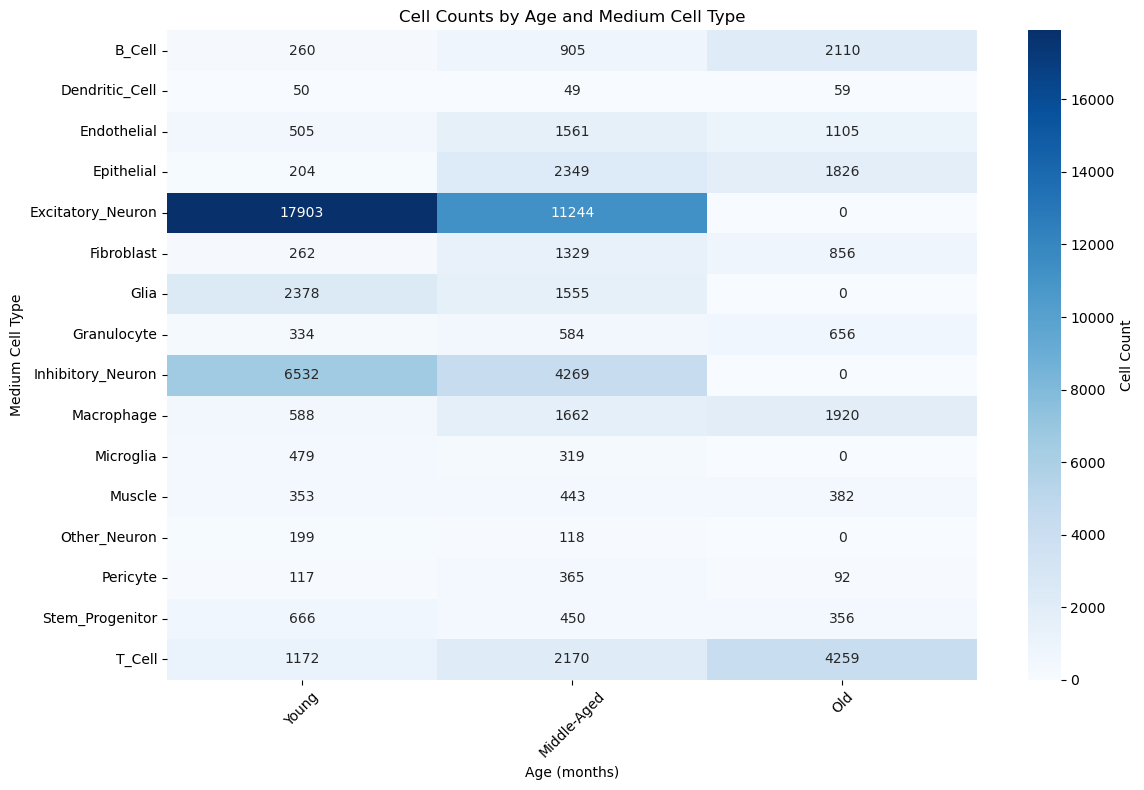

In [10]:
def create_age_celltype_heatmap(splice_adata, output_dir):
    """Create heatmap of cell counts by age and cell type."""
    print("Creating age vs cell type heatmap...")
    
    heatmap_data = pd.crosstab(
        splice_adata.obs['refined_cell_type'], 
        splice_adata.obs['age_group']
    ).fillna(0)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, 
                annot=True, 
                fmt='g', 
                cmap='Blues',
                cbar_kws={'label': 'Cell Count'})
    plt.title('Cell Counts by Age and Medium Cell Type')
    plt.xlabel('Age (months)')
    plt.ylabel('Medium Cell Type')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.savefig(f"{output_dir}/age_vs_celltype_heatmap.pdf", bbox_inches='tight')
    plt.show()

# Run EDA
create_age_celltype_heatmap(splice_adata, paths['output_dir'])

## 9. Ridge Regression Analysis

In [11]:
def run_tissue_ridge_analysis(splice_adata, ge_adata, covariate="refined_cell_type", 
                             alphas=np.logspace(-2, 3, 20)):
    """
    Run ridge regression analysis by tissue/cell type.
    """
    print(f"Running ridge regression analysis by {covariate}...")
    
    # Extract features
    assert all(splice_adata.obs_names == ge_adata.obs_names)
    
    dirichlet_data = splice_adata.obsm["X_PHI"]
    scvi_data = ge_adata.obsm["X_scVI_linear"]
    age = splice_adata.obs['age_numeric'].values
    
    results = {}
    feature_importance_data = []
    
    n_splice_factors = dirichlet_data.shape[1]
    n_scvi_factors = scvi_data.shape[1]
    
    splice_factor_names = [f"SP_{i+1}" for i in range(n_splice_factors)]
    scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
    
    for tissue in tqdm(splice_adata.obs[covariate].unique()):
        mask = (splice_adata.obs[covariate] == tissue).values
        if mask.sum() < 100 or len(np.unique(age[mask])) == 1:
            continue
            
        # Get tissue-specific data
        X_sp = StandardScaler().fit_transform(dirichlet_data[mask])
        X_sc = StandardScaler().fit_transform(scvi_data[mask])
        X_comb = np.hstack([X_sp, X_sc])
        y = age[mask]
        
        # Fit models
        ridge_sp = RidgeCV(alphas=alphas, cv=5).fit(X_sp, y)
        ridge_sc = RidgeCV(alphas=alphas, cv=5).fit(X_sc, y)
        ridge_comb = RidgeCV(alphas=alphas, cv=5).fit(X_comb, y)
        
        # Get R² scores
        r2_sp = ridge_sp.score(X_sp, y)
        r2_sc = ridge_sc.score(X_sc, y)
        r2_comb = ridge_comb.score(X_comb, y)
        
        # Statistical tests
        n = len(y)
        rss_sp = np.sum((y - ridge_sp.predict(X_sp))**2)
        rss_sc = np.sum((y - ridge_sc.predict(X_sc))**2)
        rss_comb = np.sum((y - ridge_comb.predict(X_comb))**2)
        
        # F-tests
        f_vs_sp = ((rss_sp - rss_comb) / n_scvi_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sp = 1 - stats.f.cdf(f_vs_sp, n_scvi_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        f_vs_sc = ((rss_sc - rss_comb) / n_splice_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sc = 1 - stats.f.cdf(f_vs_sc, n_splice_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        results[tissue] = {
            'n_cells': mask.sum(),
            'splice_r2': r2_sp,
            'scvi_r2': r2_sc,
            'combined_r2': r2_comb,
            'p_combined_vs_splice': p_vs_sp,
            'p_combined_vs_scvi': p_vs_sc
        }
        
        # Feature importance
        combined_coefs = ridge_comb.coef_
        splice_coefs = combined_coefs[:n_splice_factors]
        scvi_coefs = combined_coefs[n_splice_factors:]
        
        for i, coef in enumerate(splice_coefs):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Splicing',
                'factor_name': splice_factor_names[i],
                'coefficient': coef,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc
            })
        
        for i, coef in enumerate(scvi_coefs):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Gene_Expression',
                'factor_name': scvi_factor_names[i],
                'coefficient': coef,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc
            })
    
    return results, pd.DataFrame(feature_importance_data)

from scipy import stats
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

def bootstrap_ridge_coefficients(X, y, alphas=np.logspace(-2, 3, 20), n_bootstrap=100):
    """
    Bootstrap Ridge regression to get coefficient confidence intervals.
    """
    n_features = X.shape[1]
    bootstrap_coefs = []
    
    # Fit original model to get best alpha
    ridge = RidgeCV(alphas=alphas, cv=5).fit(X, y)
    best_alpha = ridge.alpha_
    
    # Bootstrap sampling
    for i in range(n_bootstrap):
        # Resample with replacement
        X_boot, y_boot = resample(X, y, random_state=i)
        
        # Fit ridge with best alpha
        ridge_boot = RidgeCV(alphas=[best_alpha], cv=3).fit(X_boot, y_boot)
        bootstrap_coefs.append(ridge_boot.coef_)
    
    bootstrap_coefs = np.array(bootstrap_coefs)
    
    # Calculate confidence intervals (2.5% and 97.5% percentiles)
    ci_lower = np.percentile(bootstrap_coefs, 2.5, axis=0)
    ci_upper = np.percentile(bootstrap_coefs, 97.5, axis=0)
    
    return ridge.coef_, ci_lower, ci_upper, ridge.score(X, y)


def run_tissue_ridge_analysis_with_ci(splice_adata, ge_adata, covariate="medium_cell_type",
                                     alphas=np.logspace(-2, 3, 20), n_bootstrap=50):
    """
    Enhanced ridge regression analysis with confidence intervals.
    """
    print(f"Running ridge regression analysis with CI by {covariate}...")
    
    # Extract features
    assert all(splice_adata.obs_names == ge_adata.obs_names)
    
    dirichlet_data = splice_adata.obsm["X_PHI"]
    scvi_data = ge_adata.obsm["X_scVI_linear"]
    age = splice_adata.obs['age_numeric'].values
    
    results = {}
    feature_importance_data = []
    
    n_splice_factors = dirichlet_data.shape[1]
    n_scvi_factors = scvi_data.shape[1]
    
    splice_factor_names = [f"SP_{i+1}" for i in range(n_splice_factors)]
    scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
    
    for tissue in splice_adata.obs[covariate].unique():
        mask = (splice_adata.obs[covariate] == tissue).values
        if mask.sum() < 100 or len(np.unique(age[mask])) == 1:
            continue
        
        print(f"  Processing {tissue} ({mask.sum()} cells)...")
        
        # Get tissue-specific data
        X_sp = StandardScaler().fit_transform(dirichlet_data[mask])
        X_sc = StandardScaler().fit_transform(scvi_data[mask])
        X_comb = np.hstack([X_sp, X_sc])
        y = age[mask]
        
        # Fit models with confidence intervals
        sp_coef, sp_ci_low, sp_ci_high, r2_sp = bootstrap_ridge_coefficients(X_sp, y, alphas, n_bootstrap)
        sc_coef, sc_ci_low, sc_ci_high, r2_sc = bootstrap_ridge_coefficients(X_sc, y, alphas, n_bootstrap)
        comb_coef, comb_ci_low, comb_ci_high, r2_comb = bootstrap_ridge_coefficients(X_comb, y, alphas, n_bootstrap)
        
        # Statistical tests (same as before)
        ridge_sp = RidgeCV(alphas=alphas, cv=5).fit(X_sp, y)
        ridge_sc = RidgeCV(alphas=alphas, cv=5).fit(X_sc, y)
        ridge_comb = RidgeCV(alphas=alphas, cv=5).fit(X_comb, y)
        
        n = len(y)
        rss_sp = np.sum((y - ridge_sp.predict(X_sp))**2)
        rss_sc = np.sum((y - ridge_sc.predict(X_sc))**2)
        rss_comb = np.sum((y - ridge_comb.predict(X_comb))**2)
        
        f_vs_sp = ((rss_sp - rss_comb) / n_scvi_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sp = 1 - stats.f.cdf(f_vs_sp, n_scvi_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        f_vs_sc = ((rss_sc - rss_comb) / n_splice_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sc = 1 - stats.f.cdf(f_vs_sc, n_splice_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        results[tissue] = {
            'n_cells': mask.sum(),
            'splice_r2': r2_sp,
            'scvi_r2': r2_sc,
            'combined_r2': r2_comb,
            'p_combined_vs_splice': p_vs_sp,
            'p_combined_vs_scvi': p_vs_sc
        }
        
        # Store coefficients with confidence intervals
        # Combined model coefficients
        splice_coefs_comb = comb_coef[:n_splice_factors]
        scvi_coefs_comb = comb_coef[n_splice_factors:]
        splice_ci_low_comb = comb_ci_low[:n_splice_factors]
        splice_ci_high_comb = comb_ci_high[:n_splice_factors]
        scvi_ci_low_comb = comb_ci_low[n_splice_factors:]
        scvi_ci_high_comb = comb_ci_high[n_splice_factors:]
        
        for i, (coef, ci_low, ci_high) in enumerate(zip(splice_coefs_comb, splice_ci_low_comb, splice_ci_high_comb)):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Splicing',
                'factor_name': splice_factor_names[i],
                'coefficient': coef,
                'ci_lower': ci_low,
                'ci_upper': ci_high,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc,
                'significant': ci_low * ci_high > 0  # CI doesn't cross zero
            })
        
        for i, (coef, ci_low, ci_high) in enumerate(zip(scvi_coefs_comb, scvi_ci_low_comb, scvi_ci_high_comb)):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Gene_Expression',
                'factor_name': scvi_factor_names[i],
                'coefficient': coef,
                'ci_lower': ci_low,
                'ci_upper': ci_high,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc,
                'significant': ci_low * ci_high > 0
            })
    
    return results, pd.DataFrame(feature_importance_data)

In [12]:
# subset ge_adata by final splice_adata 
ge_adata = ge_adata[splice_adata.obs_names]
assert np.all(ge_adata.obs_names == splice_adata.obs_names)
ge_adata.obs["refined_cell_type"] = splice_adata.obs["refined_cell_type"]

In [13]:
# Run ridge regression analysis
results, feature_importance_df = run_tissue_ridge_analysis(splice_adata, ge_adata)

Running ridge regression analysis by refined_cell_type...


100%|██████████| 16/16 [00:15<00:00,  1.01it/s]


In [14]:
# Run analysis with confidence intervals
results_ci, feature_df_ci = run_tissue_ridge_analysis_with_ci(splice_adata, ge_adata, covariate="refined_cell_type", n_bootstrap=50)

Running ridge regression analysis with CI by refined_cell_type...
  Processing Inhibitory_Neuron (10801 cells)...
  Processing Excitatory_Neuron (29147 cells)...
  Processing Glia (3933 cells)...
  Processing Microglia (798 cells)...
  Processing Other_Neuron (317 cells)...
  Processing Endothelial (3171 cells)...
  Processing Pericyte (574 cells)...
  Processing Fibroblast (2447 cells)...
  Processing Macrophage (4170 cells)...
  Processing Epithelial (4379 cells)...
  Processing B_Cell (3275 cells)...
  Processing T_Cell (7601 cells)...
  Processing Dendritic_Cell (158 cells)...
  Processing Granulocyte (1574 cells)...
  Processing Muscle (1178 cells)...
  Processing Stem_Progenitor (1472 cells)...


## 10. Results Visualization

In [15]:
def create_performance_plot(results, output_dir):
    """Create performance comparison plot."""
    # Create summary DataFrame
    summary_data = []
    for tissue, res in results.items():
        summary_data.append({
            'tissue': tissue,
            'n_cells': res['n_cells'],
            'LeafletFA_r2': res['splice_r2'],
            'scVI_r2': res['scvi_r2'],
            'LeafletFA_scVI_r2': res['combined_r2'],
            'p_combined_vs_LeafletFA': res['p_combined_vs_splice'],
            'p_combined_vs_scVI': res['p_combined_vs_scvi']
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # FDR correction
    summary_df["p_combined_vs_scVI_fdr"] = multipletests(
        summary_df["p_combined_vs_scVI"], method="fdr_bh"
    )[1]
    
    # Sort and reshape for plotting
    summary_df_sorted = summary_df.sort_values('LeafletFA_r2', ascending=False)
    
    plot_data = []
    for _, row in summary_df_sorted.iterrows():
        for model in ['LeafletFA', 'scVI', 'LeafletFA_scVI']:
            plot_data.append({
                'tissue': row['tissue'],
                'model': model,
                'r2': row[f'{model}_r2']
            })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    sns.barplot(data=plot_df, x='tissue', y='r2', hue='model', ax=ax, alpha=0.8)
    
    # Add significance markers
    for i, (_, row) in enumerate(summary_df_sorted.iterrows()):
        p_val = row['p_combined_vs_scVI_fdr']
        sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        
        if sig_text:
            combined_r2 = row['LeafletFA_scVI_r2']
            ax.text(i, combined_r2 + 0.02, sig_text, ha='center', va='bottom', 
                   fontweight='bold', fontsize=10)
    
    ax.set_xlabel('Cell Type', fontsize=14)
    ax.set_ylabel('Age Prediction Ridge Regression R²', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(f'{output_dir}/age_prediction_performance.pdf', dpi=300, bbox_inches='tight')
    print(f"Saved plot to {output_dir}/age_prediction_performance.pdf")
    plt.show()
    
    return summary_df

In [16]:
def create_correlation_analysis_with_gene_loadings(splice_adata, ge_adata, output_dir):
    """Create correlation analysis between scVI and LeafletFA factors with top gene loadings."""
    print("Computing factor correlations with gene loading annotations...")
    
    X_PHI = splice_adata.obsm["X_PHI"]
    X_scVI = ge_adata.obsm["X_scVI_linear"]
    scvi_gene_loadings = ge_adata.varm["scVI_linear_gene_loadings"]
    gene_names = ge_adata.var["gene_name"].values
    
    n_scvi_factors = X_scVI.shape[1]
    n_splicing_factors = X_PHI.shape[1]
    
    # Compute correlations
    corr_matrix = np.zeros((n_scvi_factors, n_splicing_factors))
    pval_matrix = np.zeros((n_scvi_factors, n_splicing_factors))
    
    for i in range(n_scvi_factors):
        for j in range(n_splicing_factors):
            rho, pval = spearmanr(X_scVI[:, i], X_PHI[:, j])
            corr_matrix[i, j] = rho
            pval_matrix[i, j] = pval
    
    # FDR correction
    _, pvals_fdr_flat, _, _ = multipletests(pval_matrix.flatten(), method='fdr_bh')
    fdr_matrix = pvals_fdr_flat.reshape(pval_matrix.shape)
    
    # Create significance annotations
    fdr_thresh = 0.05
    rho_thresh = 0.2
    annot_matrix = np.where(
        (fdr_matrix < fdr_thresh) & (np.abs(corr_matrix) > rho_thresh),
        "*", ""
    )
    
    # Create scVI factor labels with top 5 genes
    scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
    scvi_labels_with_genes = []
    gene_loading_summary = []
    
    for i, factor_name in enumerate(scvi_factor_names):
        # Get top 5 genes by absolute loading values
        factor_loadings = scvi_gene_loadings.iloc[:, i].values
        top_gene_indices = np.argsort(-np.abs(factor_loadings))[:5]  # Top 5 genes
        top_genes = gene_names[top_gene_indices]
        top_loadings = factor_loadings[top_gene_indices]
        
        # Create label with top 3 genes for display (to keep labels readable)
        gene_label = f"{factor_name}: {', '.join(top_genes[:5])}"
        scvi_labels_with_genes.append(gene_label)
        
        # Store detailed info for all top 5 genes
        gene_loading_summary.append({
            'Factor': factor_name,
            'Top_Gene_1': top_genes[0],
            'Loading_1': top_loadings[0],
            'Top_Gene_2': top_genes[1],
            'Loading_2': top_loadings[1],
            'Top_Gene_3': top_genes[2],
            'Loading_3': top_loadings[2],
            'Top_Gene_4': top_genes[3],
            'Loading_4': top_loadings[3],
            'Top_Gene_5': top_genes[4],
            'Loading_5': top_loadings[4],
            'Top_3_Display': ', '.join(top_genes[:3]),
            'Top_5_All': ', '.join(top_genes)
        })
    
    splicing_factor_names = [f"SP_{i+1}" for i in range(n_splicing_factors)]
    
    # Create correlation DataFrame
    corr_df = pd.DataFrame(
        corr_matrix,
        index=scvi_labels_with_genes,
        columns=splicing_factor_names
    )
    
    # Create clustermap with PRGn colormap
    plt.figure(figsize=(8,6))  # Increased size for gene labels
    
    g = sns.clustermap(
        corr_df,
        cmap="PRGn",
        center=0,
        linewidths=0.3,
        linecolor="white",
        xticklabels=True,
        yticklabels=True,
        annot=annot_matrix,
        fmt='',
        annot_kws={'size': 8, 'color': 'black', 'weight': 'bold'},
        figsize=(8,6),
        cbar_kws={'label': 'Spearman Correlation', 'shrink': 0.8},
        col_cluster=False,  # Don't cluster columns (keep SP order)
        row_cluster=True   # Cluster rows (scVI factors)
    )
    
    g.ax_heatmap.set_xlabel("LeafletFA Splicing Programs", fontsize=14, fontweight='bold')
    g.ax_heatmap.set_ylabel("scVI Latent Factors (Top Genes)", fontsize=14, fontweight='bold')
    
    # Adjust label formatting
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=10)
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)
    
    # Add significance legend
    legend_text = f"* Significant: FDR < {fdr_thresh}, |ρ| > {rho_thresh}"
    g.fig.text(0.02, 0.98, legend_text, fontsize=11, style='italic',
               verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", 
               facecolor="lightgray", alpha=0.7))
    
    # Save the plot
    output_path = f"{output_dir}/scVI_leafletFA_correlation_with_gene_loadings.pdf"
    g.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    # Save correlation matrix with gene annotations
    corr_df.to_csv(f"{output_dir}/scVI_leafletFA_correlations_with_gene_loadings.csv")
    
    # Save detailed gene loading summary
    gene_loading_df = pd.DataFrame(gene_loading_summary)
    gene_loading_df.to_csv(f"{output_dir}/scVI_top5_gene_loadings_summary.csv", index=False)
    
    print(f"Saved correlation analysis with gene loadings to: {output_path}")
    print(f"Saved detailed gene loading summary to: {output_dir}/scVI_top5_gene_loadings_summary.csv")
    
    # Print summary of top genes
    print("\nTop 5 gene loadings for each scVI factor:")
    for i, summary in enumerate(gene_loading_summary):
        print(f"  {summary['Factor']}: {summary['Top_5_All']}")
        if i >= 9:  # Show first 10 factors
            remaining = len(gene_loading_summary) - 10
            if remaining > 0:
                print(f"  ... and {remaining} more factors (see CSV for complete list)")
            break
    
    return corr_df, gene_loading_df

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/age_prediction_performance.pdf


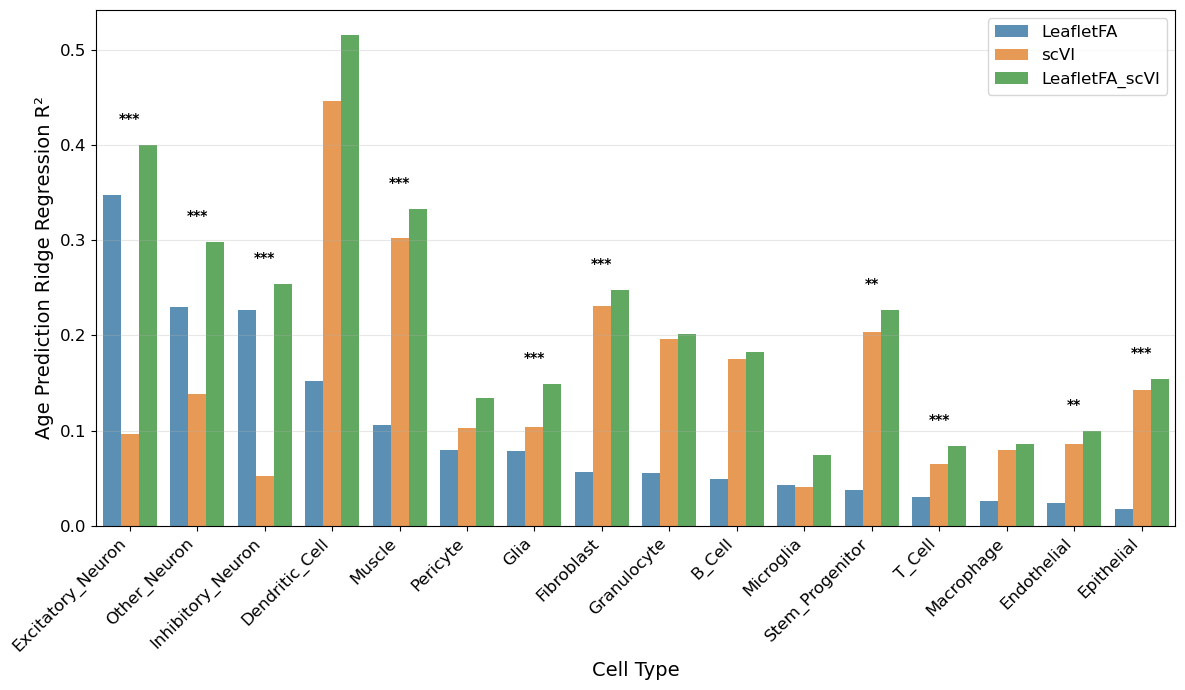

In [17]:
# Run visualizations
summary_df = create_performance_plot(results, paths['output_dir'])

In [18]:
#sc.pl.umap(ge_adata, color=[SCVI_CLUSTERS_KEY])
#zs = [f"Z_{i}" for i in 20]
#sc.pl.umap(ge_adata, color=zs, ncols=3)

In [19]:
ge_adata.layers["scVI_linear"] = ge_adata.obsm["X_normalized_scVI_linear"]

Computing factor correlations with gene loading annotations...


<Figure size 800x600 with 0 Axes>

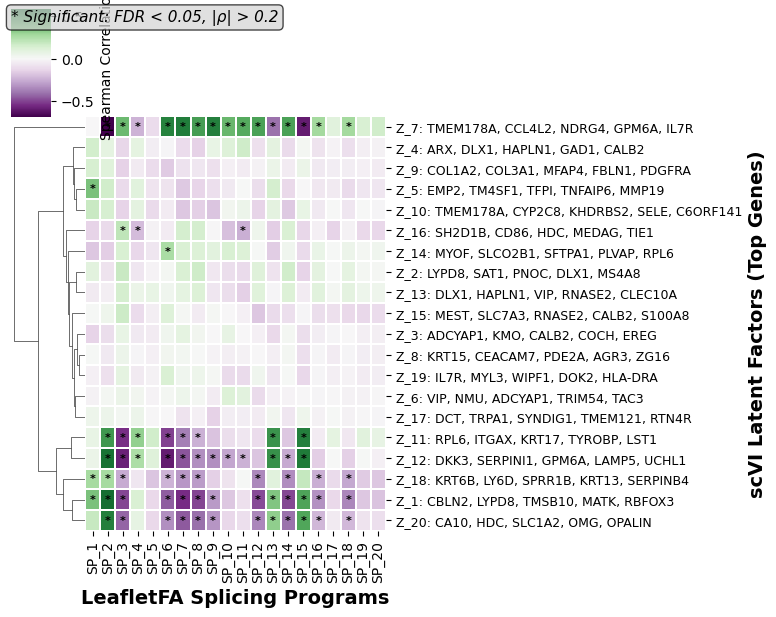

Saved correlation analysis with gene loadings to: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/scVI_leafletFA_correlation_with_gene_loadings.pdf
Saved detailed gene loading summary to: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/scVI_top5_gene_loadings_summary.csv

Top 5 gene loadings for each scVI factor:
  Z_1: CBLN2, LYPD8, TMSB10, MATK, RBFOX3
  Z_2: LYPD8, SAT1, PNOC, DLX1, MS4A8
  Z_3: ADCYAP1, KMO, CALB2, COCH, EREG
  Z_4: ARX, DLX1, HAPLN1, GAD1, CALB2
  Z_5: EMP2, TM4SF1, TFPI, TNFAIP6, MMP19
  Z_6: VIP, NMU, ADCYAP1, TRIM54, TAC3
  Z_7: TMEM178A, CCL4L2, NDRG4, GPM6A, IL7R
  Z_8: KRT15, CEACAM7, PDE2A, AGR3, ZG16
  Z_9: COL1A2, COL3A1, MFAP4, FBLN1, PDGFRA
  Z_10: TMEM178A, CYP2C8, KHDRBS2, SELE, C6ORF141
  ... and 10 more factors (see CSV for complete list

In [20]:
# Replace your correlation analysis call with:
corr_df, gene_loading_df = create_correlation_analysis_with_gene_loadings(
    splice_adata, ge_adata, paths['output_dir']
)

In [21]:
# rename columns ge_adata.varm["scVI_linear_gene_loadings"] to be Z_1 to Z_20 
ge_adata.varm["scVI_linear_gene_loadings"].columns = [f"Z_{i}" for i in range(1, 21)]
print(ge_adata.varm["scVI_linear_gene_loadings"].head())

             Z_1       Z_2       Z_3       Z_4       Z_5       Z_6       Z_7  \
VCP    -0.082661  0.014871  0.159949 -0.103201 -0.136884 -0.042942 -0.263593   
PLA2G5  0.487890  0.630970 -0.334706  0.302744  0.611683 -0.081830  0.483391   
OAS1   -0.064454 -0.100223  0.272546 -0.199607 -0.111994  0.067639 -0.658690   
ACTG1  -0.008517  0.088890  0.096735 -0.022661  0.083169  0.077327 -0.731646   
ASPA    0.656031  0.997262 -0.627897  0.032887  1.008516 -0.374120  0.549079   

             Z_8       Z_9      Z_10      Z_11      Z_12      Z_13      Z_14  \
VCP    -0.008673 -0.110827 -0.028055 -0.137488  0.015850 -0.210519  0.111311   
PLA2G5 -0.027093  1.043649  0.204225  0.787781 -0.214501  0.317319 -0.396943   
OAS1    0.058018  0.084317 -0.291460  0.127602  0.126340 -0.290002 -0.252860   
ACTG1  -0.124075 -0.100441  0.051612 -0.196849 -0.116875 -0.183687  0.179710   
ASPA   -0.346788  0.153657  0.665186 -0.033646  0.539174  0.001234 -0.732844   

            Z_15      Z_16      Z_17  

##  Visualize Factor Activity in a Given Cell Type

In [22]:
def plot_factor_activity_by_age(
    adata,
    factor_matrix_key,
    factor_prefix,
    factor_index,
    cell_type_name,
    obs_col="refined_cell_type",
    age_col="age_numeric"
):
    """
    Plot a specific factor's activity across ages within a selected cell type.
    Adds cell counts to x-axis labels and adjusts color if factor is gene expression.
    """
    # Filter to the target cell type
    mask = adata.obs[obs_col] == cell_type_name
    if mask.sum() == 0:
        print(f"No cells found for cell type: {cell_type_name}")
        return

    # Get data
    factor_values = adata.obsm[factor_matrix_key][mask, factor_index]
    ages = adata.obs.loc[mask, age_col]

    # Build DataFrame
    factor_label = f"{factor_prefix}_{factor_index + 1}"
    df = pd.DataFrame({
        factor_label: factor_values,
        "age": ages
    })

    # Compute counts and relabel x-axis
    age_counts = df["age"].value_counts().sort_index()
    age_labels = [f"{int(age)} (n={count})" for age, count in age_counts.items()]
    age_order = age_counts.index.tolist()

    # Choose color palette
    if factor_prefix.upper().startswith("Z"):
        violin_color = "#4C72B0"  # blue for gene expression
    else:
        violin_color = "#55A868"  # green for splicing

    # Plot
    plt.figure(figsize=(6, 4))
    sns.violinplot(
        data=df, x="age", y=factor_label,
        order=age_order,
        inner="box", linewidth=1, color=violin_color
    )
    sns.stripplot(
        data=df, x="age", y=factor_label,
        order=age_order,
        color="black", alpha=0.3, jitter=0.2, size=2
    )

    # Set custom x-tick labels
    plt.xticks(ticks=range(len(age_labels)), labels=age_labels, rotation=0)
    plt.title(f"{factor_label} Activity in {cell_type_name} by Age", fontsize=13)
    plt.xlabel("Age (with cell counts)")
    plt.ylabel("Factor Activity")
    plt.tight_layout()
    plt.show()

In [23]:
ge_adata.obs["age_numeric"] = splice_adata.obs["age_numeric"]

In [24]:
plot_factor_activity_by_age(splice_adata, "X_PHI", "SP", factor_index=10, cell_type_name="Bladder cell", obs_col="broad_cell_type")
plot_factor_activity_by_age(ge_adata, "X_scVI_linear", "Z", factor_index=14, cell_type_name="Cardiomyocyte", obs_col="broad_cell_type")

No cells found for cell type: Bladder cell
No cells found for cell type: Cardiomyocyte


## Correlation Between SP and Z Factors in a Given Cell Type

In [25]:
def plot_sp_z_correlation(splice_adata, ge_adata, sp_index, z_index, cell_type_name, obs_col="medium_cell_type"):
    """
    Scatter plot of SP and Z factor activity for a specific cell type.
    """
    # Add option to plot all cells 
    # Make hexbin version to group points into high density regions
    mask = splice_adata.obs[obs_col] == cell_type_name
    sp_val = splice_adata.obsm["X_PHI"][mask, sp_index]
    z_val = ge_adata.obsm["X_scVI_linear"][mask, z_index]
    
    df = pd.DataFrame({
        f"SP_{sp_index+1}": sp_val,
        f"Z_{z_index+1}": z_val
    })

    corr = np.corrcoef(sp_val, z_val)[0, 1]
    
    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=f"SP_{sp_index+1}", y=f"Z_{z_index+1}", data=df, s=20, alpha=0.7, edgecolor='black')
    plt.title(f"{cell_type_name}: SP_{sp_index+1} vs Z_{z_index+1}\nPearson r = {corr:.2f}")
    plt.tight_layout()
    plt.show()

In [26]:
from scipy import stats

def create_factor_barplot_summary(feature_importance_df, output_dir):
    """
    Publication-ready bar plot showing mean coefficients with error bars
    and annotations for consistency.
    """
    print("🔍 Creating factor summary barplot...")
    
    # Pivot to wide format
    coef_matrix = feature_importance_df.pivot_table(
        index='cell_type',
        columns='factor_name',
        values='coefficient',
        fill_value=0
    )
    
    # Calculate stats
    factor_means = coef_matrix.mean()
    factor_stds = coef_matrix.std()
    
    # Updated consistency: proportion with strong effects (>0.5 or <-0.5) in same direction
    factor_consistency = coef_matrix.apply(lambda x: max((x > 0.5).sum(), (x < -0.5).sum()) / len(x))
    
    # Separate SP and Z factors
    sp_factors = sorted([f for f in factor_means.index if f.startswith("SP_")], 
                       key=lambda x: int(x.split("_")[1]))
    z_factors = sorted([f for f in factor_means.index if f.startswith("Z_")], 
                      key=lambda x: int(x.split("_")[1]))
    
    # Create subplot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 11), sharex=False)
    
    # SP factors (LeafletFA) - Blue
    sp_means = factor_means[sp_factors]
    sp_stds = factor_stds[sp_factors]
    sp_consistency = factor_consistency[sp_factors]
    
    bars1 = ax1.bar(range(len(sp_factors)), sp_means, yerr=sp_stds, 
                    capsize=5, alpha=0.8, color='#1f77b4', edgecolor='black',
                    width=0.7, linewidth=1.5)
    ax1.set_xticks(range(len(sp_factors)))
    ax1.set_xticklabels([f.replace('SP_', '') for f in sp_factors], fontsize=14)
    ax1.set_ylabel('Mean Coefficient ± SD\nAcross Cell Types', fontweight='bold', fontsize=16)
    ax1.set_title('LeafletFA Splicing Programs - Aging Association', fontweight='bold', fontsize=18)
    ax1.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1.5)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='both', which='major', labelsize=14)
    
    # Add consistency annotations
    for i, (bar, consistency) in enumerate(zip(bars1, sp_consistency)):
        height = bar.get_height()
        if consistency > 0.3:  # Show if >30% have strong effects
            ax1.annotate(f'{consistency:.0%}',
                        xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 10 if height >= 0 else -25),
                        textcoords="offset points",
                        ha='center', va='bottom' if height >= 0 else 'top',
                        fontsize=13, fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.9, edgecolor='gray'))
    
    # Z factors (scVI) - Orange  
    z_means = factor_means[z_factors]
    z_stds = factor_stds[z_factors]
    z_consistency = factor_consistency[z_factors]
    
    bars2 = ax2.bar(range(len(z_factors)), z_means, yerr=z_stds,
                    capsize=5, alpha=0.8, color='#ff7f0e', edgecolor='black',
                    width=0.7, linewidth=1.5)
    ax2.set_xticks(range(len(z_factors)))
    ax2.set_xticklabels([f.replace('Z_', '') for f in z_factors], fontsize=14)
    ax2.set_xlabel('Factor Number', fontweight='bold', fontsize=16)
    ax2.set_ylabel('Mean Coefficient ± SD\nAcross Cell Types', fontweight='bold', fontsize=16)
    ax2.set_title('scVI Gene Expression Factors - Aging Association', fontweight='bold', fontsize=18)
    ax2.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1.5)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='both', which='major', labelsize=14)
    
    # Add consistency annotations
    for i, (bar, consistency) in enumerate(zip(bars2, z_consistency)):
        height = bar.get_height()
        if consistency > 0.3:  # Show if >30% have strong effects
            ax2.annotate(f'{consistency:.0%}',
                        xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 10 if height >= 0 else -25),
                        textcoords="offset points",
                        ha='center', va='bottom' if height >= 0 else 'top',
                        fontsize=13, fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.9, edgecolor='gray'))
    
    # Add note about consistency
    fig.text(0.02, 0.02, 'Consistency %: Proportion with strong effects (>|0.5|) in same direction (>30% shown)', 
             fontsize=12, style='italic', alpha=0.7)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    
    # Save
    output_path = f"{output_dir}/factor_aging_barplot_summary.pdf"
    print(f"📁 Saving to: {output_path}")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Done! Consistency = % of cell types with strong effects (>|0.5|) in same direction")


🔍 Creating factor summary barplot...
📁 Saving to: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/factor_aging_barplot_summary.pdf


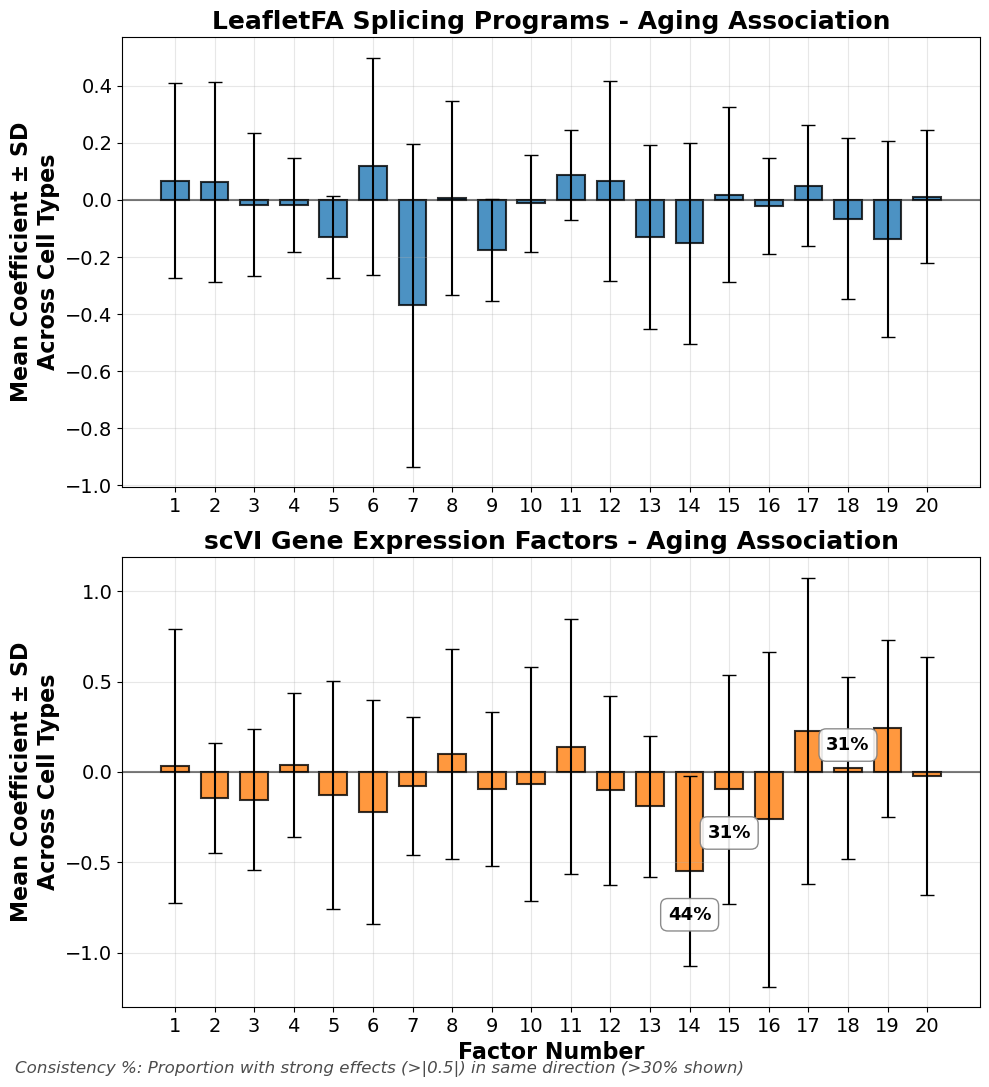

✅ Done! Consistency = % of cell types with strong effects (>|0.5|) in same direction


In [27]:
# Example usage:
create_factor_barplot_summary(feature_importance_df, paths['output_dir'])

In [28]:
def create_forest_plot_single_celltype(feature_df, cell_type, output_dir, top_n_factors=10, figsize=(4, 4)):
    """Create a simple forest plot for a single cell type."""
    
    # Filter and get top factors
    ct_data = feature_df[feature_df['cell_type'] == cell_type].copy()
    ct_data = ct_data.nlargest(top_n_factors, 'abs_coefficient').sort_values('coefficient')
    
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    colors = {'Splicing': '#1f77b4', 'Gene_Expression': '#ff7f0e'}
    
    for i, (_, row) in enumerate(ct_data.iterrows()):
        ax.errorbar(row['coefficient'], i, 
                   xerr=[[row['coefficient'] - row['ci_lower']], [row['ci_upper'] - row['coefficient']]], 
                   fmt='o', color=colors[row['factor_type']], capsize=3, markersize=6, alpha=0.8)
        
        factor_label = row['factor_name']
        ax.text(row['coefficient'], i, f"  {factor_label}", va='center', 
               ha='left' if row['coefficient'] >= 0 else 'right', fontsize=10)
    
    # Format
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Ridge Regression Coefficient ± 95% CI', fontweight='bold', fontsize=11)
    ax.set_ylabel('Top Factors', fontweight='bold', fontsize=11)
    ax.set_title(cell_type, fontweight='bold', fontsize=12)
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=12)
    ax.grid(True, alpha=0.3, axis='x')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors['Splicing'], label='LeafletFA'),
                      Patch(facecolor=colors['Gene_Expression'], label='scVI')]
    ax.legend(handles=legend_elements, loc='best', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/forest_plot_{cell_type.replace(' ', '_').replace('/', '_')}.pdf", 
                dpi=300, bbox_inches='tight')
    print(f"Saved file to {output_dir}/forest_plot_{cell_type.replace(' ', '_').replace('/', '_')}.pdf")
    plt.show()

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_Inhibitory_Neuron.pdf


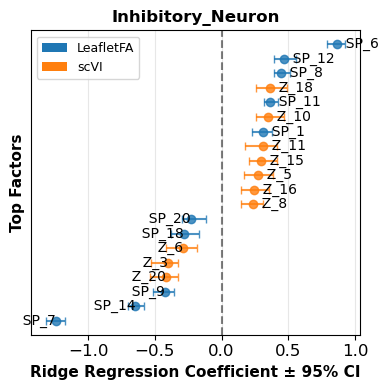

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_Excitatory_Neuron.pdf


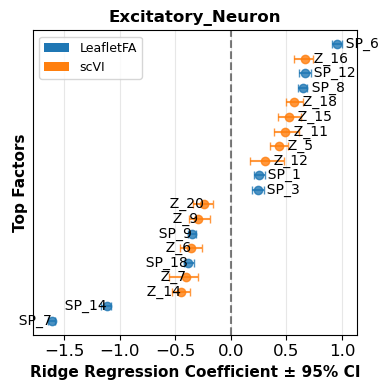

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_Glia.pdf


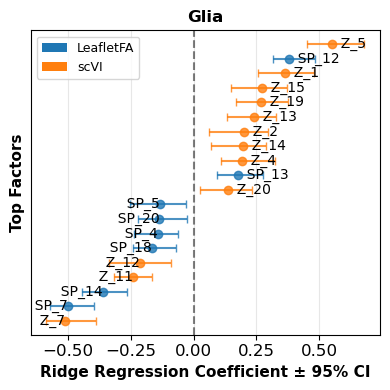

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_Microglia.pdf


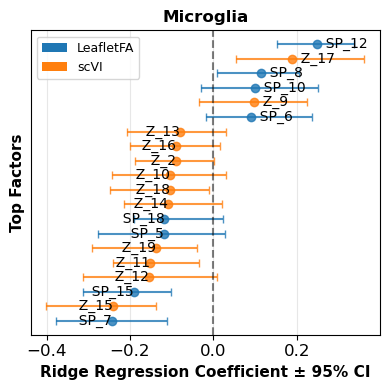

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_Other_Neuron.pdf


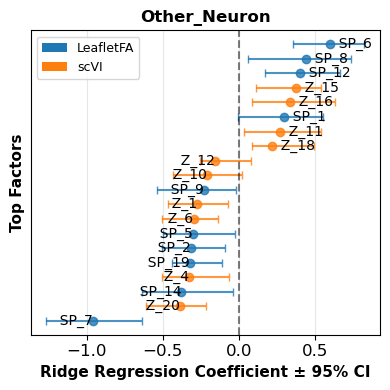

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_Endothelial.pdf


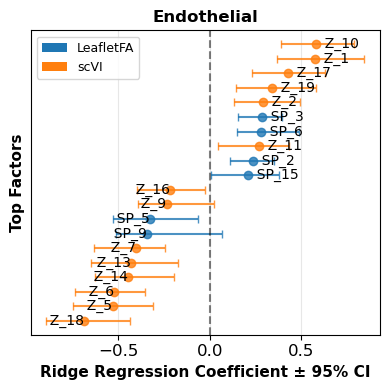

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_Pericyte.pdf


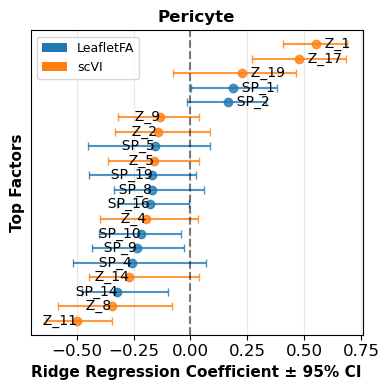

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_Fibroblast.pdf


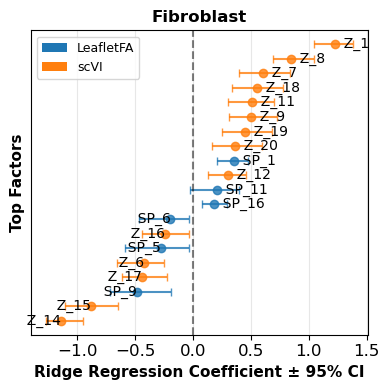

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_Macrophage.pdf


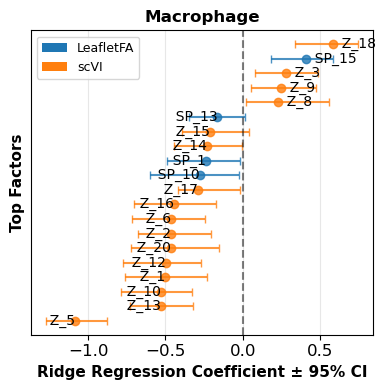

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_Epithelial.pdf


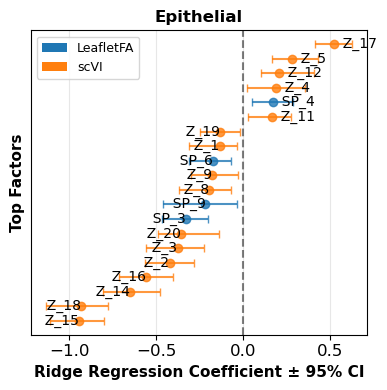

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_B_Cell.pdf


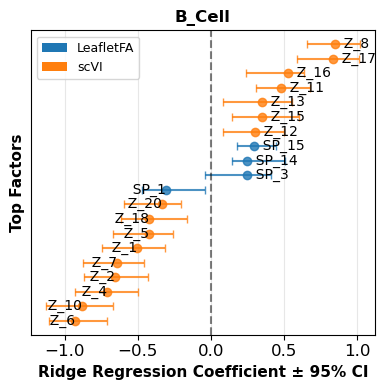

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_T_Cell.pdf


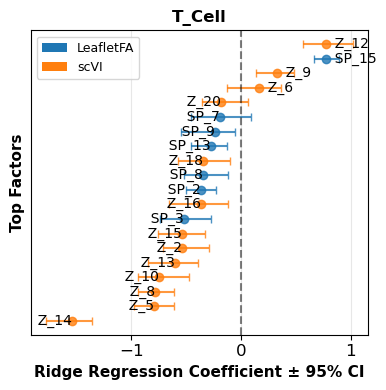

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_Dendritic_Cell.pdf


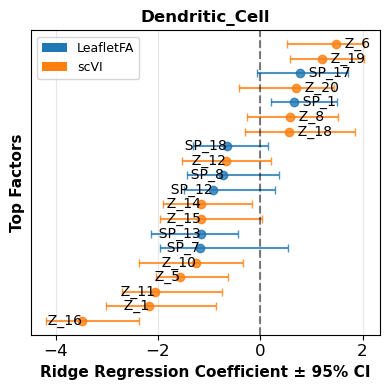

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_Granulocyte.pdf


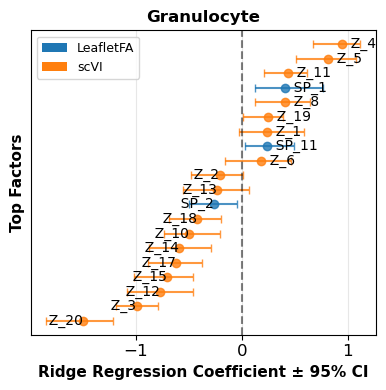

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_Muscle.pdf


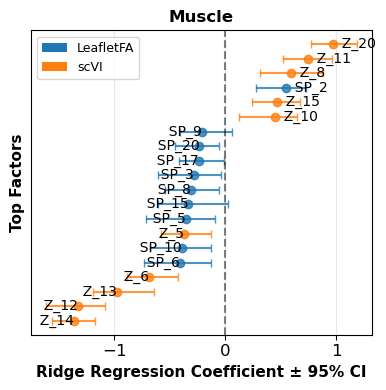

Saved file to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/forest_plot_Stem_Progenitor.pdf


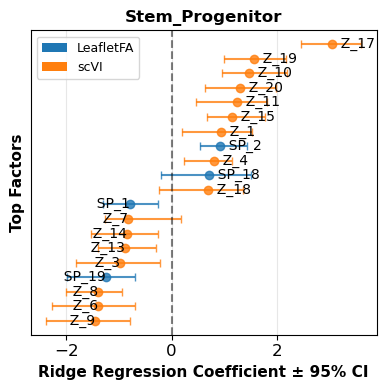

In [29]:
# Make forest plot for every cell type! 
for cell_type in splice_adata.obs["refined_cell_type"].unique():
    create_forest_plot_single_celltype(feature_df_ci, cell_type, paths["output_dir"], top_n_factors=20, figsize=(4, 4))

## Load LeafletFA SP junction markers 
Obtained from `/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/NatureAging_PLOTTING_MOUSE/MOUSE_FIGURE_PLOTS.ipynb`

In [31]:
sj_markers = "/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/final_df.tsv.gz"
sj_markers_df = pd.read_csv(sj_markers, sep="\t")
sj_markers_df.head()

,old_factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif_y,donor_seq,acceptor_seq,position_off_5_prime_y,position_off_3_prime_y,junction_annotation
0,0,0,0.089327,0.089327,0.000564,0.0,0.0,1.0,False,0.2,...,0.9857,1.0000,308769,304354,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1,0,1,-0.003928,0.003928,0.000049,0.0,0.0,1.0,False,0.2,...,0.0124,0.0135,308769,282160,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
2,0,2,-0.010230,0.010230,0.001179,0.0,0.0,1.0,False,0.2,...,1.0000,0.9199,36841,40047,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
3,0,3,0.137641,0.137641,0.000289,0.0,0.0,1.0,False,0.2,...,0.0801,0.1020,40047,31445,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
4,0,4,-0.073357,0.073357,0.001422,0.0,0.0,1.0,False,0.2,...,0.8980,1.0000,31445,28239,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated


Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/sj_markers_aging_effect_size.pdf


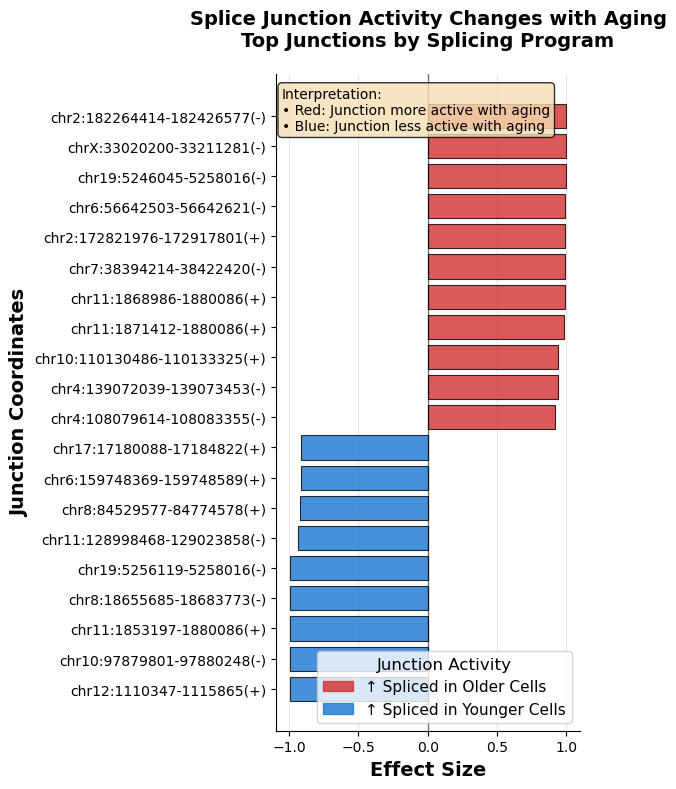

In [39]:
# Set style
plt.style.use('default')

# Define the important factors and their age associations
important_factors = [0, 1]  # SP_1, SP_2, SP_7, SP_11

# Age association direction for each factor (from your feature_df_ci)
age_associations = {
    0: 'positive',   # SP_1: positive coefficient = more active in older cells
    1: 'positive'   # SP_2: negative coefficient = more active in younger cells  
}

# Filter for significant junctions
filtered_df = sj_markers_df[
    (sj_markers_df["factor_idx"].isin(important_factors)) & 
    (sj_markers_df["significant"]) & 
    (sj_markers_df["abs_effect_size"] > 0.25)
].copy()

# Get top N junctions per factor
top_n_per_factor = 10
top_junctions = []
for factor in important_factors:
    factor_data = filtered_df[filtered_df["factor_idx"] == factor]
    if len(factor_data) > 0:
        top_factor_junctions = factor_data.nlargest(top_n_per_factor, 'abs_effect_size')
        top_junctions.append(top_factor_junctions)

plot_data = pd.concat(top_junctions, ignore_index=True)

# Create junction labels
plot_data['junction_label'] = plot_data['junction_id'].str.replace('_', ':', 1).str.replace('_', '-', 1).str.replace('_', '(', 1) + ')'

# Create interpretable effect direction
plot_data['age_direction'] = plot_data.apply(lambda row: 
    'Older' if (age_associations[row['factor_idx']] == 'positive' and row['effect_size'] > 0) or 
              (age_associations[row['factor_idx']] == 'negative' and row['effect_size'] < 0)
    else 'Younger', axis=1)

# Create factor labels with age direction
plot_data['sp_label'] = 'SP_' + (plot_data['factor_idx'] + 1).astype(str)

# Define colors based on age direction instead of just factor
plot_data['color'] = plot_data['age_direction'].map({
    'Older': '#d32f2f',    # Red for increased splicing in older cells
    'Younger': '#1976d2'   # Blue for increased splicing in younger cells
})

# Create the plot
plt.figure(figsize=(6, 8))

# Sort by effect size
plot_data_sorted = plot_data.sort_values('effect_size', ascending=True)

# Create barplot
bars = plt.barh(range(len(plot_data_sorted)), plot_data_sorted['effect_size'], 
                color=plot_data_sorted['color'], 
                alpha=0.8, edgecolor='black', linewidth=0.8)

# Customize labels
plt.yticks(range(len(plot_data_sorted)), 
           plot_data_sorted['junction_label'],
           fontsize=10)

plt.xlabel('Effect Size', fontsize=14, fontweight='bold')
plt.ylabel('Junction Coordinates', fontsize=14, fontweight='bold')
plt.title('Splice Junction Activity Changes with Aging\nTop Junctions by Splicing Program', 
          fontsize=14, fontweight='bold', pad=20)

# Add vertical line at x=0
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5, linewidth=1)

# Add gene names and SP labels with colored SP text
for i, (bar, row) in enumerate(zip(bars, plot_data_sorted.itertuples())):
    width = bar.get_width()
    # gene_name = getattr(row, 'gene_name_y', getattr(row, 'gene_name', 'Unknown'))
    sp_label = f"SP_{getattr(row, 'factor_idx')+1}"
    factor_idx = getattr(row, 'factor_idx')
    
    # Define SP colors for text
    sp_text_colors = {0: '#2E86AB', 1: '#A23B72', 10: '#F18F01'}  # Distinct colors for each SP
    
    # Position at the end of the bar
    x_pos = width + (0.05 if width >= 0 else -0.05)
    
    # Create the label with gene name in black and SP in color
    #plt.text(x_pos, bar.get_y() + bar.get_height()/2, 
    #         gene_name, ha='left' if width >= 0 else 'right', 
    #         va='center', fontsize=9, style='italic', color='black')
    
    # Add SP label in different color, slightly offset
    #sp_x_offset = len(gene_name) * 0.008  # Approximate offset based on gene name length
    # sp_x_pos = x_pos + (sp_x_offset if width >= 0 else -sp_x_offset)
    
    #plt.text(sp_x_pos, bar.get_y() + bar.get_height()/2, 
    #         f' ({sp_label})', ha='left' if width >= 0 else 'right', 
   #          va='center', fontsize=9, style='italic', 
   #          color=sp_text_colors.get(factor_idx, 'black'), fontweight='bold')

# Create age-direction legend
legend_elements = [
    plt.Rectangle((0,0),1,1, color='#d32f2f', alpha=0.8, label='↑ Spliced in Older Cells'),
    plt.Rectangle((0,0),1,1, color='#1976d2', alpha=0.8, label='↑ Spliced in Younger Cells')
]

plt.legend(handles=legend_elements, title='Junction Activity', title_fontsize=12, fontsize=11, 
           loc='lower right')

# Add text box explaining interpretation
textstr = 'Interpretation:\n• Red: Junction more active with aging\n• Blue: Junction less active with aging'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

# Grid and styling
plt.grid(True, alpha=0.3, axis='x')
plt.gca().set_axisbelow(True)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{paths['output_dir']}/sj_markers_aging_effect_size.pdf", dpi=300, bbox_inches='tight')
# print where plot was saved 
print(f"Plot saved to {paths['output_dir']}/sj_markers_aging_effect_size.pdf")
plt.show()

In [53]:
plot_data.sort_values(by="junction_idx")

,old_factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,acceptor_total_reads,splice_motif_y,donor_seq,acceptor_seq,position_off_5_prime_y,position_off_3_prime_y,junction_annotation,age_direction,sp_label,color
3,10,81,0.942242,0.942242,0.000065,100.0,1.0,0.0,True,0.2,...,368627,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated,Older,SP_1,#d32f2f
14,1,818,-0.992679,0.992679,0.000118,100.0,1.0,0.0,True,0.2,...,119360,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated,Younger,SP_2,#1976d2
4,10,1071,-0.936879,0.936879,0.000280,100.0,1.0,0.0,True,0.2,...,50349,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated,Younger,SP_1,#1976d2
0,10,1144,-0.992562,0.992562,0.000078,100.0,1.0,0.0,True,0.2,...,335084,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated,Younger,SP_1,#1976d2
1,10,1145,0.987987,0.987987,0.000080,100.0,1.0,0.0,True,0.2,...,50426,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated,Older,SP_1,#d32f2f
2,10,1147,0.979479,0.979479,0.000243,100.0,1.0,0.0,True,0.2,...,58681,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated,Older,SP_1,#d32f2f
11,1,2041,-0.994883,0.994883,0.000021,100.0,1.0,0.0,True,0.2,...,158966,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated,Younger,SP_2,#1976d2
9,10,5674,-0.913165,0.913165,0.000084,100.0,1.0,0.0,True,0.2,...,211404,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated,Younger,SP_1,#1976d2
13,1,7586,0.994298,0.994298,0.000020,100.0,1.0,0.0,True,0.2,...,11048,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated,Older,SP_2,#d32f2f
16,1,7587,-0.991289,0.991289,0.000033,100.0,1.0,0.0,True,0.2,...,77631,GT-AG,GT,AG,1.0,NaN,5_prime_annotated,Younger,SP_2,#1976d2


In [40]:
splice_adata.layers["denoised_PSI"] = splice_adata.obsm["X_PHI"] @ splice_adata.varm["psi_learned"].T

In [45]:
def plot_psi_by_age_violin(splice_adata, junction_idx, age_col="age_numeric", OUTPUT_DIR=None, figsize=(4, 4)):
    """
    Create a violin plot showing denoised PSI values by age for a single junction
    """
        
    # Get denoised PSI data and age
    junction_psi = splice_adata.layers["denoised_PSI"][:, junction_idx]  # All cells for this junction
    ages = splice_adata.obs[age_col].values
    junction_id = splice_adata.var["junction_id"].values[junction_idx]

    # Create dataframe for plotting
    plot_df = pd.DataFrame({
        'PSI': junction_psi,
        'Age': ages
    })
    
    # Remove any NaN values
    plot_df = plot_df.dropna()
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Create violin plot with age as continuous variable
    sns.violinplot(data=plot_df, x='Age', y='PSI', 
                  color='#1976d2', alpha=0.7)
    
    # Customize plot
    title = f'Junction {junction_id}'
    plt.title(title, fontsize=11, fontweight='bold')
    plt.xlabel('Age (Months)', fontsize=11, fontweight='bold')
    plt.ylabel('Denoised Junction \nUsage Ratio', fontsize=11, fontweight='bold')

    # Increase tick font size 
    plt.tick_params(axis='both', which='major', labelsize=12)
    
    # Add grid
    plt.grid(True, alpha=0.3)
    plt.gca().set_axisbelow(True)
    
    plt.tight_layout()
    if OUTPUT_DIR:
        plt.savefig(f"{OUTPUT_DIR}/psi_by_age_violin_{junction_id}.pdf", dpi=300, bbox_inches='tight')
        print(f"Plot saved to {OUTPUT_DIR}/psi_by_age_violin_{junction_id}.pdf")
    plt.show()

In [59]:
plot_data_sorted.sort_values(by="effect_size", ascending=False).iloc[0][["junction_id"]]

junction_id    chr2_182264414_182426577_-
Name: 10, dtype: object

Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/psi_by_age_violin_chr2_182264414_182426577_-.pdf


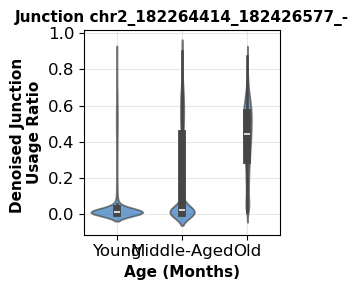

In [46]:
plot_psi_by_age_violin(splice_adata, junction_idx=11395, age_col="age_group", OUTPUT_DIR=paths["output_dir"], figsize=(3, 3))

In [49]:
splice_adata.var[splice_adata.var["junction_id_index"] == 11395]

,junction_id,event_id,splice_motif,annotation_status,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,clean_gene_id,...,mean_counts_per_cell,junction_variability,annotation_status_score,expression_breadth_score,read_count_score,variability_score,conservation_score,junction_id_index,RBP_gene,Aging_gene
11395,chr2_182264414_182426577_-,ENSG00000115252.19_atse_1,GT-AG,both,ENSG00000115252,2,1.0,0.0,38867,ENSG00000115252,...,62.083916,0.085115,0.5,0.0,9.784535,0.5,1.0,11395,False,False


In [64]:
atse_df[atse_df["junction_id"] == "chr2_182264414_182426577_-"]

,event_id,gene_id,gene_name,gene_types,num_junctions,event_type,chromosome,strand,atse_start,atse_end,...,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif,donor_seq,acceptor_seq,position_off_5_prime,position_off_3_prime,junction_annotation


In [61]:
junction_id="chr2_182264414_182426577_-"
event= splice_adata.var[splice_adata.var["junction_id"] == junction_id]["event_id"].values[0]
visualize_atse_event(event, atse_df, db_human,
                     base_width=6,
                 species="mouse", show_usage=False, 
                 trans_height=0.7,
                  show_junc_lines=False)

No junctions found for ATSE event: ENSG00000115252.19_atse_1


In [ ]:
plot_psi_by_age_violin(splice_adata, junction_idx=33890, OUTPUT_DIR=paths["output_dir"], figsize=(3, 3))

In [47]:
feature_importance_df[feature_importance_df["factor_type"] == "Splicing"].sort_values(by="coefficient", ascending=False)[0:20]

,cell_type,factor_type,factor_name,coefficient,abs_coefficient,combined_r2,p_vs_scvi
45,Excitatory_Neuron,Splicing,SP_6,0.950845,0.950845,0.399412,1.110223e-16
601,Stem_Progenitor,Splicing,SP_2,0.920506,0.920506,0.226754,2.914893e-03
5,Inhibitory_Neuron,Splicing,SP_6,0.863491,0.863491,0.254355,1.110223e-16
454,T_Cell,Splicing,SP_15,0.772738,0.772738,0.084070,1.110223e-16
496,Dendritic_Cell,Splicing,SP_17,0.769276,0.769276,0.515699,6.608788e-01
617,Stem_Progenitor,Splicing,SP_18,0.708245,0.708245,0.226754,2.914893e-03
619,Stem_Progenitor,Splicing,SP_20,0.683669,0.683669,0.226754,2.914893e-03
51,Excitatory_Neuron,Splicing,SP_12,0.662936,0.662936,0.399412,1.110223e-16
480,Dendritic_Cell,Splicing,SP_1,0.660283,0.660283,0.515699,6.608788e-01
47,Excitatory_Neuron,Splicing,SP_8,0.647816,0.647816,0.399412,1.110223e-16


In [48]:
feature_importance_df[feature_importance_df["factor_type"] == "Splicing"].sort_values(by="coefficient", ascending=True)[0:20]

,cell_type,factor_type,factor_name,coefficient,abs_coefficient,combined_r2,p_vs_scvi
46,Excitatory_Neuron,Splicing,SP_7,-1.612163,1.612163,0.399412,1.110223e-16
618,Stem_Progenitor,Splicing,SP_19,-1.252948,1.252948,0.226754,2.914893e-03
6,Inhibitory_Neuron,Splicing,SP_7,-1.240055,1.240055,0.254355,1.110223e-16
486,Dendritic_Cell,Splicing,SP_7,-1.184052,1.184052,0.515699,6.608788e-01
492,Dendritic_Cell,Splicing,SP_13,-1.157414,1.157414,0.515699,6.608788e-01
53,Excitatory_Neuron,Splicing,SP_14,-1.118980,1.118980,0.399412,1.110223e-16
166,Other_Neuron,Splicing,SP_7,-0.960006,0.960006,0.298230,1.324061e-05
491,Dendritic_Cell,Splicing,SP_12,-0.921758,0.921758,0.515699,6.608788e-01
600,Stem_Progenitor,Splicing,SP_1,-0.789396,0.789396,0.226754,2.914893e-03
487,Dendritic_Cell,Splicing,SP_8,-0.719232,0.719232,0.515699,6.608788e-01


## RBP analysis FIgure 4 !

In [71]:
SP1_cells = feature_importance_df[feature_importance_df["factor_name"] == "SP_1"].sort_values(by="coefficient", ascending=False)[0:20]
SP2_cells = feature_importance_df[feature_importance_df["factor_name"] == "SP_2"].sort_values(by="coefficient", ascending=True)[0:20]

In [85]:
# Keep only where combined_r2 > 0.5 and p_vs_scvi < 0.05
SP1_cells = SP1_cells[SP1_cells["combined_r2"] > 0.2]
SP2_cells = SP2_cells[SP2_cells["combined_r2"] > 0.2]
SP1_cells = SP1_cells[SP1_cells["p_vs_scvi"] < 0.05]
SP2_cells = SP2_cells[SP2_cells["p_vs_scvi"] < 0.05]

assert all(ge_adata.obs_names == splice_adata.obs_names)

In [87]:
assert all(ge_adata.obs_names == splice_adata.obs_names)

In [86]:
ge_adata.layers["scVI_linear"] = ge_adata.obsm["X_normalized_scVI_linear"]

### Running RBP expression vs SP1, SP2 and age correlation

In [88]:
# 2. Get overlapping cell types between SP1 and SP2
sp1_cell_types = set(SP1_cells['cell_type'].values)
sp2_cell_types = set(SP2_cells['cell_type'].values)
overlapping_cell_types = list(sp1_cell_types & sp2_cell_types)
print(f"\nOverlapping cell types: length {len(overlapping_cell_types)}")
print(overlapping_cell_types)

# 1. Extract RBP genes and their expression
print("Extracting RBP genes...")
rbp_genes = ge_adata.var[ge_adata.var['is_rbp']].index.tolist()
print(f"Found {len(rbp_genes)} RBP genes")

# 3. Ensure SP scores are in ge_adata
if 'SP_1' not in ge_adata.obs.columns:  
    # Match cells between splice_adata and ge_adata
    ge_adata.obs.loc[:, 'SP_1'] = splice_adata.obs.loc[:, 'SP_1']   
    ge_adata.obs.loc[:, 'SP_2'] = splice_adata.obs.loc[:, 'SP_2']


Overlapping cell types: length 6
['Excitatory_Neuron', 'Other_Neuron', 'Muscle', 'Fibroblast', 'Inhibitory_Neuron', 'Stem_Progenitor']
Extracting RBP genes...
Found 307 RBP genes


In [89]:
from statsmodels.stats.multitest import multipletests
import pingouin as pg

def simple_mediation_analysis(ge_adata_aging, splicing_aging, rbp_genes, cell_type, n_boot=1000):
    """Simple mediation analysis for one cell type."""
    
    # Align splicing data
    for col in ["SP_1", "SP_2"]:
        if col not in ge_adata_aging.obs.columns:
            ge_adata_aging.obs[col] = splicing_aging.obs[col].reindex(ge_adata_aging.obs_names).values
    
    # Subset to cell type
    mask = ge_adata_aging.obs["refined_cell_type"] == cell_type
    ct = ge_adata_aging[mask].copy()
    print(f"{cell_type}: {ct.n_obs} cells")
    
    # Skip cell type if too few cells
    if ct.n_obs <= 500:
        print(f"Skipping {cell_type}: only {ct.n_obs} cells")
        return pd.DataFrame()
        
    # Get available RBPs
    available_rbps = [rbp for rbp in rbp_genes if rbp in ct.var_names]
    print(f"Testing {len(available_rbps)} RBPs")
    
    # Run mediation for all RBPs
    results = []
    for rbp in tqdm(available_rbps):
        # Get RBP expression
        rbp_expr = np.asarray(ct[:, rbp].layers["scVI_linear"]).ravel()
        
        # Skip if no variation
        if np.std(rbp_expr) == 0:
            continue
            
        # Skip if RBP is expressed in fewer than 5% of cells
        if np.mean(rbp_expr > 0) < 0.05:
            continue

        # Build dataframe
        df = pd.DataFrame({
            "Age": ct.obs["age_numeric"].values,
            "RBP_expr": rbp_expr,
            "SP1": ct.obs["SP_1"].values,
            "SP2": ct.obs["SP_2"].values
        })
        
        # Test each outcome
        for outcome in ["SP1", "SP2"]:
            d = df[["Age", "RBP_expr", outcome]].dropna().rename(columns={outcome: "Y"})
            
            if len(d) < 50 or d["Y"].std() == 0:
                continue
                
            try:
                res = pg.mediation_analysis(data=d, x="Age", m="RBP_expr", y="Y", n_boot=n_boot, seed=42)
                res["RBP"] = rbp
                res["Outcome"] = outcome
                res["CellType"] = cell_type
                results.append(res)
            except:
                continue
    
    # Combine results
    if not results:
        return pd.DataFrame()
        
    all_results = pd.concat(results, ignore_index=True)
    print(all_results.head)
    
    # FDR correction for indirect effects only
    indirect = all_results[all_results['path'] == 'Indirect'].copy()
    _, pvals_corrected, _, _ = multipletests(indirect['pval'], method='fdr_bh')
    indirect['pval_fdr'] = pvals_corrected
    
    # Get significant mediations
    indirect['effect_size'] = np.abs(indirect['coef'])
    indirect = indirect.sort_values('effect_size', ascending=False)
    
    return indirect

# Usage:
all_res = []
for cell_type in tqdm(overlapping_cell_types): # cell types with strong SP1/SP2 coefficients 
    results = simple_mediation_analysis(ge_adata, splice_adata, rbp_genes, cell_type, n_boot=10)
    all_res.append(results)

  0%|          | 0/6 [00:00<?, ?it/s]

Excitatory_Neuron: 29147 cells
Testing 307 RBPs


 17%|█▋        | 1/6 [01:28<07:21, 88.38s/it]

<bound method NDFrame.head of               path          coef            se          pval  CI[2.5%]  \
0     RBP_expr ~ X  3.697564e-06  2.764091e-07  1.084527e-40  0.000003   
1     Y ~ RBP_expr  1.230889e+00  8.757276e-01  1.598650e-01 -0.485577   
2            Total  8.471616e-04  4.115407e-05  1.727657e-93  0.000766   
3           Direct  8.477839e-04  4.128090e-05  4.596977e-93  0.000767   
4         Indirect -6.222701e-07  4.547599e-06  4.000000e-01 -0.000004   
...            ...           ...           ...           ...       ...   
3065  RBP_expr ~ X  1.409196e-06  1.589597e-07  8.068125e-19  0.000001   
3066  Y ~ RBP_expr -1.450172e+00  3.895111e-01  1.971954e-04 -2.213632   
3067         Total -6.120409e-05  1.058102e-05  7.354738e-09 -0.000082   
3068        Direct -5.932004e-05  1.059333e-05  2.165849e-08 -0.000080   
3069      Indirect -1.884049e-06  5.256761e-07  0.000000e+00 -0.000003   

      CI[97.5%]  sig    RBP Outcome           CellType  
0      0.000004  Yes  SR

 50%|█████     | 3/6 [01:42<01:24, 28.12s/it]

...

<bound method NDFrame.head of               path          coef            se          pval    CI[2.5%]  \
0     RBP_expr ~ X -8.981409e-07  1.383574e-07  1.025911e-10   -0.000001   
1     Y ~ RBP_expr -9.935007e+01  4.607729e+01  3.116831e-02 -189.704629   
2            Total  2.348498e-03  3.146738e-04  1.166517e-13    0.001731   
3           Direct  2.298205e-03  3.173425e-04  5.894934e-13    0.001676   
4         Indirect  5.029245e-05  5.805185e-05  4.000000e-01   -0.000022   
...            ...           ...           ...           ...         ...   
3065  RBP_expr ~ X -4.553017e-06  1.010319e-06  6.900429e-06   -0.000007   
3066  Y ~ RBP_expr  5.229198e+01  7.307604e+00  1.094581e-12   37.962251   
3067         Total  1.319558e-03  3.694366e-04  3.613655e-04    0.000595   
3068        Direct  1.570583e-03  3.668018e-04  1.925196e-05    0.000851   
3069      Indirect -2.510244e-04  1.092426e-04  0.000000e+00   -0.000450   

         CI[97.5%]  sig    RBP Outcome    CellType  
0   

 83%|████████▎ | 5/6 [02:46<00:31, 31.68s/it]

<bound method NDFrame.head of               path      coef            se          pval      CI[2.5%]  \
0     RBP_expr ~ X  0.000002  4.487745e-07  1.432660e-07  1.482895e-06   
1     Y ~ RBP_expr -9.806532  2.414272e+00  4.901889e-05 -1.453895e+01   
2            Total  0.001179  1.122504e-04  1.127814e-25  9.587888e-04   
3           Direct  0.001205  1.122886e-04  9.828549e-27  9.849675e-04   
4         Indirect -0.000026  6.544563e-06  0.000000e+00 -3.535576e-05   
...            ...       ...           ...           ...           ...   
3065  RBP_expr ~ X  0.000001  3.653887e-07  2.956156e-03  3.700488e-07   
3066  Y ~ RBP_expr -3.259365  5.907746e-01  3.525789e-08 -4.417392e+00   
3067         Total -0.000085  2.245796e-05  1.571628e-04 -1.289310e-04   
3068        Direct -0.000081  2.243775e-05  2.854101e-04 -1.254174e-04   
3069      Indirect -0.000003  1.049087e-06  0.000000e+00 -4.659357e-06   

      CI[97.5%]  sig    RBP Outcome           CellType  
0      0.000003  Yes  SR

100%|██████████| 6/6 [03:00<00:00, 30.10s/it]

<bound method NDFrame.head of               path          coef            se          pval      CI[2.5%]  \
0     RBP_expr ~ X  8.932877e-07  1.788317e-07  6.582857e-07  5.424952e-07   
1     Y ~ RBP_expr -3.729965e+02  4.491104e+01  2.233851e-16 -4.610931e+02   
2            Total -1.405657e-03  3.156153e-04  9.078414e-06 -2.024761e-03   
3           Direct -1.090667e-03  3.119712e-04  4.862506e-04 -1.702624e-03   
4         Indirect -3.149896e-04  5.469678e-05  0.000000e+00 -3.779794e-04   
...            ...           ...           ...           ...           ...   
3065  RBP_expr ~ X  9.318306e-07  1.038474e-06  3.697016e-01 -1.105218e-06   
3066  Y ~ RBP_expr  3.243334e+01  8.299083e+00  9.726829e-05  1.615404e+01   
3067         Total  1.684886e-03  3.293176e-04  3.526797e-07  1.038904e-03   
3068        Direct  1.655570e-03  3.278942e-04  4.994025e-07  1.012380e-03   
3069      Indirect  2.931608e-05  4.020168e-05  1.000000e+00 -2.784418e-05   

       CI[97.5%]  sig    RBP Outc

In [91]:
all_res_df = pd.concat(all_res, ignore_index=True)

# Significant SPdiff hits
sig_hits = (
    all_res_df
    .query("path == 'Indirect' and pval_fdr < 0.05 and Outcome == 'SP2'")
    .copy()
)

# Top 5 per cell type
top_per_cell = (
    sig_hits
    .sort_values(["CellType", "effect_size"], ascending=[True, False])
    .groupby("CellType")
    .head(5)
)

# Keep only these RBPs & cell types in the full results
rbps_keep = top_per_cell["RBP"].unique()
cell_types_keep = top_per_cell["CellType"].unique()

subset_df = all_res_df[
    all_res_df["RBP"].isin(rbps_keep) &
    all_res_df["CellType"].isin(cell_types_keep) &
    (all_res_df["Outcome"] == "SP2") &
    (all_res_df["path"] == "Indirect")
].copy()

# Pivot to RBP × CellType matrix (effect size or coef)
heatmap_df = subset_df.pivot(index="RBP", columns="CellType", values="coef").fillna(0)
value_col = "coef" if "coef" in subset_df.columns else "effect_size"

In [92]:
print(f"The number of RBPs is {heatmap_df.shape[0]} and the number of cell types is {heatmap_df.shape[1]}")

The number of RBPs is 18 and the number of cell types is 5


In [93]:
# Choose value column
value_col = "coef" if "coef" in subset_df.columns else "effect_size"

# Collapse to one row per (RBP, CellType): take the row with the smallest FDR
pair_df = (
    subset_df.sort_values("pval_fdr")
             .drop_duplicates(["RBP", "CellType"])
)

# Values for heatmap
heatmap_df = (
    pair_df.pivot(index="RBP", columns="CellType", values=value_col)
           .fillna(0)
)

# Significance mask (FDR<0.05)
sig_mask = (
    (pair_df.assign(sig=lambda d: d["pval_fdr"] < 0.05))
    .pivot(index="RBP", columns="CellType", values="sig")
    .fillna(False)
)

# Ensure same index/columns in both
sig_mask = sig_mask.reindex(index=heatmap_df.index, columns=heatmap_df.columns, fill_value=False)

In [94]:
rbp_summary = {}
for rbp in heatmap_df.index:
    sig_vals = []
    for ct in heatmap_df.columns:
        if sig_mask.loc[rbp, ct]:
            sig_vals.append(heatmap_df.loc[rbp, ct])

    if not sig_vals:  # no significant hits
        rbp_summary[rbp] = "No significant associations"
        continue

    pos_frac = sum(v > 0 for v in sig_vals) / len(sig_vals)
    neg_frac = sum(v < 0 for v in sig_vals) / len(sig_vals)

    if pos_frac >= 0.75:
        rbp_summary[rbp] = "Broad aging-promoter (positive in most cell types)"
    elif neg_frac >= 0.75:
        rbp_summary[rbp] = "Broad youth-associated / aging-protective (negative in most cell types)"
    else:
        rbp_summary[rbp] = "Mixed / cell-type-specific effect"

rbp_summary_df = pd.DataFrame.from_dict(rbp_summary, orient="index", columns=["Interpretation"])
rbp_summary_df["Interpretation"].value_counts()

Interpretation
Mixed / cell-type-specific effect                                          11
Broad youth-associated / aging-protective (negative in most cell types)     5
Broad aging-promoter (positive in most cell types)                          2
Name: count, dtype: int64

RBP_SPdiff_mediation.pdf saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/RBP_SPdiff_mediation.pdf


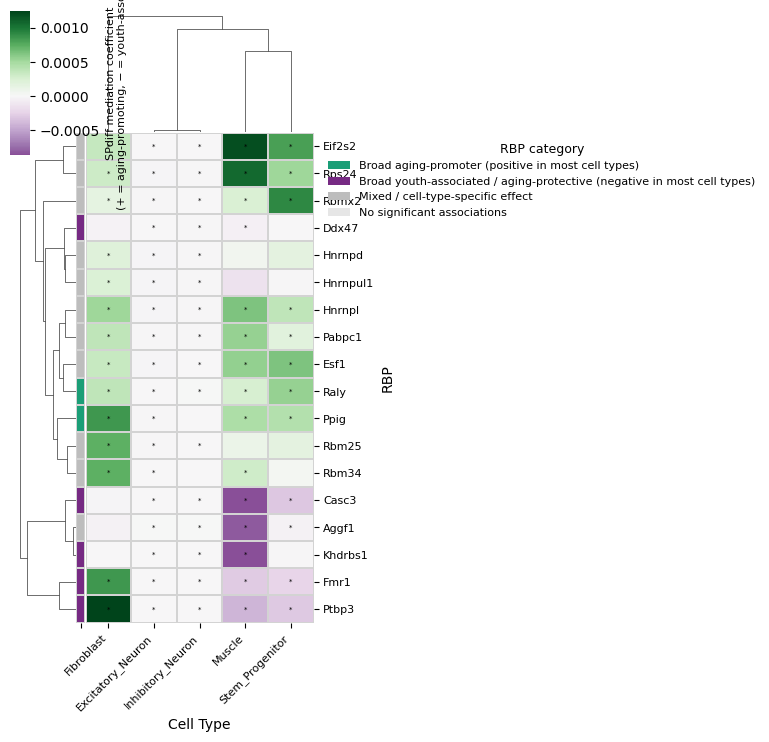

In [95]:
# --- 0) Reformat gene names to mouse style ---
heatmap_df.index = [name.capitalize() for name in heatmap_df.index]
sig_mask.index   = [name.capitalize() for name in sig_mask.index]
rbp_summary_df.index = [s.capitalize() for s in rbp_summary_df.index]

# --- 1) Choose category → color mapping ---
# (A) Match heatmap PRGn semantics (green = aging-promoter, purple = youth)
cat2color = {
    "Broad aging-promoter (positive in most cell types)"          : "#1b9e77",  # green
    "Broad youth-associated / aging-protective (negative in most cell types)" : "#762a83",  # purple
    "Mixed / cell-type-specific effect"                           : "#bdbdbd",
    "No significant associations"                                 : "#e6e6e6",
}

# # (B) Blue/Red alternative
# cat2color = {
#     "Broad aging-promoter (positive in most cell types)"          : "#d73027",  # red
#     "Broad youth-associated / aging-protective (negative in most cell types)" : "#4575b4",  # blue
#     "Mixed / cell-type-specific effect"                           : "#bdbdbd",
#     "No significant associations"                                 : "#e6e6e6",
# }

# --- 2) Build row_colors aligned to heatmap_df.index ---
row_categories = (
    pd.Series(index=heatmap_df.index, dtype=object)
      .apply(lambda _: "No significant associations")
)
row_categories.update(rbp_summary_df["Interpretation"])  # fill where we have a label
row_colors = row_categories.map(cat2color)

# --- 3) Plot with row_colors ---
figsize = (4, 8)
g = sns.clustermap(
    data=heatmap_df,
    cmap="PRGn",
    center=0,
    row_cluster=True,
    col_cluster=True,
    linewidths=0.15,
    linecolor="lightgray",
    xticklabels=True,
    yticklabels=True,
    figsize=figsize,
    row_colors=row_colors,
)

# Axis labels
g.ax_heatmap.set_xlabel("Cell Type", fontsize=10)
g.ax_heatmap.set_ylabel("RBP", fontsize=10)

# Colorbar label
g.ax_cbar.set_ylabel("SPdiff mediation coefficient\n(+ = aging-promoting, − = youth-associated)", fontsize=8)

# Rotate/align x labels cleanly
for lbl in g.ax_heatmap.get_xticklabels():
    lbl.set_rotation(45)
    lbl.set_horizontalalignment('right')
    lbl.set_fontsize(8)
g.ax_heatmap.tick_params(axis='y', labelsize=8)

# Stars for FDR<0.05
row_order = [heatmap_df.index[i]   for i in g.dendrogram_row.reordered_ind]
col_order = [heatmap_df.columns[i] for i in g.dendrogram_col.reordered_ind]
for i, rbp in enumerate(row_order):
    for j, ct in enumerate(col_order):
        if sig_mask.loc[rbp, ct]:
            g.ax_heatmap.text(j + 0.5, i + 0.5, "*",
                              ha="center", va="center",
                              fontsize=5, color="black", clip_on=True)

# Legend for the row color strip
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, edgecolor='none', label=k) for k, c in cat2color.items()]
g.ax_heatmap.legend(
    handles=handles,
    title="RBP category",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
    fontsize=8,
    title_fontsize=9
)

# --- 4) Save figure ---
plt.savefig(f"{paths['output_dir']}/RBP_SPdiff_mediation.pdf", bbox_inches='tight')
print(f"RBP_SPdiff_mediation.pdf saved to {paths['output_dir']}/RBP_SPdiff_mediation.pdf")

plt.show()

In [96]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def plot_mediation_landscape_simple(
    mediation_results,
    ge_adata_aging,
    cell_type,
    save_dir,
    effect_threshold=1e-4,
    top_labels=8,
    point_size=28,
    add_quadrant_labels=True,
):
    """
    Scatter for one cell type:
      x-axis: SPdiff mediation coefficient (Indirect path)
              (>0: aging-promoting; <0: youth-protective)
      y-axis: Spearman corr(RBP expression, age)
              (>0: RBP up with age; <0: RBP down with age)
    Color: SPdiff mediation coefficient (diverging, centered at 0)
    Saves PDF to <save_dir>/<cell_type>_RBP_landscape.pdf
    """
    # --- filter to SPdiff, indirect path, this cell type ---
    ct = mediation_results.query(
        "CellType == @cell_type and path == 'Indirect' and Outcome == 'SPdiff'"
    ).copy()
    if ct.empty:
        print(f"No SPdiff indirect rows for {cell_type}.")
        return pd.DataFrame()

    # one row per (RBP, CellType): keep smallest FDR (or pval)
    if "pval_fdr" in ct.columns:
        ct = (ct.sort_values("pval_fdr")
                .drop_duplicates(["RBP", "CellType"], keep="first"))
    else:
        ct = (ct.sort_values("pval")
                .drop_duplicates(["RBP", "CellType"], keep="first"))

    # --- compute RBP–age Spearman correlations in this cell type ---
    mask = ge_adata_aging.obs["medium_cell_type"] == cell_type
    if mask.sum() < 50:
        print(f"Too few cells for {cell_type}: {mask.sum()}")
        return pd.DataFrame()

    ages = ge_adata_aging.obs.loc[mask, "age_numeric"].astype(float).values
    rbps = [rbp for rbp in ct["RBP"].unique() if rbp in ge_adata_aging.var_names]
    if not rbps:
        print(f"No RBPs from mediation present in ge_adata_aging for {cell_type}.")
        return pd.DataFrame()

    age_corr = {}
    for rbp in rbps:
        try:
            expr = np.asarray(ge_adata_aging[mask, rbp].layers["scVI_linear"]).ravel()
        except Exception:
            expr = np.asarray(ge_adata_aging[mask, rbp].X).ravel()
        if np.std(expr) == 0 or np.isnan(expr).any():
            continue
        rho, _ = spearmanr(expr, ages)
        age_corr[rbp] = rho
    if not age_corr:
        print(f"No valid age correlations computed for {cell_type}.")
        return pd.DataFrame()

    # --- assemble plotting frame ---
    P = (
        ct.set_index("RBP")[["coef"]]
          .rename(columns={"coef": "med_coef"})
          .join(pd.Series(age_corr, name="age_corr"), how="inner")
          .dropna()
    )
    P = P.loc[P["med_coef"].abs() > effect_threshold]
    if P.empty:
        print(f"No RBPs pass |SPdiff coef| > {effect_threshold} in {cell_type}.")
        return P

    # --- plot ---
    fig, ax = plt.subplots(figsize=(4, 3))

    vmax = float(np.nanmax(np.abs(P["med_coef"])))
    sc = ax.scatter(
        P["med_coef"], P["age_corr"],
        c=P["med_coef"], cmap="PRGn", vmin=-vmax, vmax=vmax,
        s=point_size, edgecolors="black", linewidths=0.1, alpha=0.9
    )

    # axes crosshairs
    ax.axhline(0, color="black", ls="--", lw=0.6, alpha=0.5)
    ax.axvline(0, color="black", ls="--", lw=0.6, alpha=0.5)

    ax.set_xlabel("SPdiff mediation coefficient", fontsize=10)
    ax.set_ylabel("Spearman corr(RBP expression, age)", fontsize=10)
    ax.set_title(f"RBP:landscape:{cell_type}", fontsize=5, pad=6)

    for lbl in ax.get_xticklabels():
        lbl.set_rotation(45)
    ax.tick_params(axis="both", labelsize=11)

    # colorbar
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Mediation coef", fontsize=6)
    cbar.ax.tick_params(labelsize=7)

    # label top points by |coef|
    for rbp in P["med_coef"].abs().nlargest(min(top_labels, len(P))).index:
        ax.annotate(
            rbp, (P.at[rbp, "med_coef"], P.at[rbp, "age_corr"]),
            xytext=(5, 3), textcoords="offset points",
            fontsize=6, 
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
        )

    # --- quadrant annotations (axes-relative, no unpack bug) ---
    if add_quadrant_labels:
        pos = {
            "Q1": (0.78, 0.88),  # x>0,y>0
            "Q2": (0.12, 0.88),  # x<0,y>0
            "Q3": (0.12, 0.12),  # x<0,y<0
            "Q4": (0.78, 0.12),  # x>0,y<0
        }
        qtext = {
            "Q1": "Aging-promoter\n↑ with age",
            "Q2": "Youth-protective\n↑ with age",
            "Q3": "Youth-protective\n↓ with age",
            "Q4": "Aging-promoter\n↓ with age",
        }
        for q, label in qtext.items():
            x, y = pos[q]
            ax.text(
                x, y, label,
                transform=ax.transAxes,
                ha="center", va="center",
                fontsize=7,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none"),
            )

    plt.tight_layout()

    # --- save as PDF ---
    os.makedirs(save_dir, exist_ok=True)
    pdf_path = os.path.join(save_dir, f"{cell_type}_RBP_landscape.pdf")
    # replace any spaces with underscores
    pdf_path = pdf_path.replace(" ", "_")
    plt.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    plt.show()
    return P

In [97]:
all_res_df["RBP"] = all_res_df["RBP"].str.capitalize()